##Centro Universitário FMU
Disciplina: Técnicas de Machine Learning
2026.1
*  Professor Luciano Tadeu Pereira
* email luciano.tadeu@fmu.br



# Técnicas de Machine Learning
## Algoritmos de ML — Supervisionado, Não Supervisionado e Por Reforço

**Disciplina:** Técnicas de Machine Learning  

---

### Estrutura Completa do Notebook

| Aula | Tipo | Algoritmo | Tema |
|------|------|-----------|------|
| Aula 1 | ⚙️ Base | Setup | Configuração, dados e pré-processamento |
| Aula 2 | Supervisionado | Regressão Linear | Prever valores contínuos |
| Aula 3 | Supervisionado | Árvore de Decisão | Classificação com regras interpretáveis |
| Aula 4 | Supervisionado | SVM | Classificação com margem máxima |
| Aula 5 | Não Supervisionado | K-Means | Agrupamento sem rótulos |
| Aula 6 | Não Supervisionado | PCA | Redução de dimensionalidade |
| Aula 7 | Por Reforço | Q-Learning | Agente aprendendo por tentativa e erro |
| Aula 8 | Desafios | Integrador | Exercícios práticos com gabarito |

---
> 💡 **Pré-requisito:** Execute sempre a **Aula 1 (Setup)** antes de qualquer outra aula.  
> Cada aula é **independente** após o setup e pode ser explorada em aulas separadas.


---
# AULA 1 — Configuração do Ambiente e Pré-processamento

## Objetivo
Instalar bibliotecas, carregar os datasets e aplicar o pipeline de pré-processamento que será reutilizado em todas as aulas seguintes.

## Conceito-chave: Os três paradigmas de aprendizado

```
Machine Learning
├── Supervisionado    → aprende com exemplos rotulados (X → y)
│   ├── Regressão        → prevê valores contínuos  (ex: preço, temperatura)
│   └── Classificação    → prevê categorias          (ex: spam/não-spam)
│
├── Não Supervisionado → encontra padrões sem rótulos
│   ├── Clustering        → agrupa dados similares
│   └── Redução Dim.      → comprime features
│
└── Por Reforço        → agente aprende por tentativa e recompensa
    └── Q-Learning        → aprende política ótima de ações
```


In [ ]:
# ============================================================
# CÉLULA 1 — Instalação de bibliotecas
# ============================================================

!pip install pandas numpy matplotlib seaborn scikit-learn gymnasium -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score,
                              classification_report, confusion_matrix,
                              silhouette_score)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.figsize': (12, 5), 'font.size': 12})

print("✅ Bibliotecas carregadas com sucesso!")


✅ Bibliotecas carregadas com sucesso!


In [ ]:
# ============================================================
# CÉLULA 2 — Carregamento dos datasets
# ============================================================
# Usaremos 2 datasets públicos clássicos:
#   • Titanic   → classificação (Survived: 0/1)
#   • Housing   → regressão (preço mediano de casas)

# --- Dataset 1: Titanic ---
url_titanic = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df_titanic = pd.read_csv(url_titanic)
print(f"✅ Titanic:  {df_titanic.shape[0]} linhas × {df_titanic.shape[1]} colunas")

# --- Dataset 2: California Housing (sklearn built-in) ---
from sklearn.datasets import fetch_california_housing, load_iris, make_blobs
housing = fetch_california_housing(as_frame=True)
df_housing = housing.frame
print(f"✅ Housing:  {df_housing.shape[0]} linhas × {df_housing.shape[1]} colunas")

# --- Dataset 3: Iris (para SVM e K-Means) ---
iris = load_iris(as_frame=True)
df_iris = iris.frame
df_iris['target_name'] = pd.Categorical.from_codes(iris.target, iris.target_names)
print(f"✅ Iris:     {df_iris.shape[0]} linhas × {df_iris.shape[1]} colunas")

print("\n📋 Datasets disponíveis para as aulas:")
print("   df_titanic  → Aulas 3, 4 (Árvore de Decisão, SVM)")
print("   df_housing  → Aula 2    (Regressão Linear)")
print("   df_iris     → Aulas 4, 5, 6 (SVM, K-Means, PCA)")


✅ Titanic:  891 linhas × 12 colunas
✅ Housing:  20640 linhas × 9 colunas
✅ Iris:     150 linhas × 6 colunas

📋 Datasets disponíveis para as aulas:
   df_titanic  → Aulas 3, 4 (Árvore de Decisão, SVM)
   df_housing  → Aula 2    (Regressão Linear)
   df_iris     → Aulas 4, 5, 6 (SVM, K-Means, PCA)


In [ ]:
# ============================================================
# CÉLULA 3 — Pipeline de pré-processamento (reutilizável)
# ============================================================
# Este pipeline será chamado nas aulas seguintes.
# Boa prática: centralizar o pré-processamento em uma função.

def preprocessar_titanic(df):
    """Pré-processa o dataset Titanic para classificação."""
    d = df.copy()
    # Imputação
    d['Age']      = d['Age'].fillna(d['Age'].median())
    d['Embarked'] = d['Embarked'].fillna(d['Embarked'].mode()[0])
    d = d.drop(columns=['Cabin', 'Name', 'Ticket', 'PassengerId'])
    # Codificação
    d['Sex']      = LabelEncoder().fit_transform(d['Sex'])
    d['Embarked'] = LabelEncoder().fit_transform(d['Embarked'])
    # Features e target
    features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
    X = d[features]
    y = d['Survived']
    return X, y

def preprocessar_housing(df):
    """Pré-processa o dataset California Housing para regressão."""
    X = df.drop(columns=['MedHouseVal'])
    y = df['MedHouseVal']
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
    return X_scaled, y, scaler

# Preparar os dados
X_titanic, y_titanic = preprocessar_titanic(df_titanic)
X_housing, y_housing, scaler_housing = preprocessar_housing(df_housing)

# Splits treino/teste
X_tr_tit, X_te_tit, y_tr_tit, y_te_tit = train_test_split(
    X_titanic, y_titanic, test_size=0.2, random_state=42, stratify=y_titanic)

X_tr_hous, X_te_hous, y_tr_hous, y_te_hous = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42)

X_tr_iris, X_te_iris, y_tr_iris, y_te_iris = train_test_split(
    df_iris[iris.feature_names], iris.target, test_size=0.2, random_state=42)

print("✅ Pré-processamento concluído!")
print(f"   Titanic  treino: {X_tr_tit.shape}  | teste: {X_te_tit.shape}")
print(f"   Housing  treino: {X_tr_hous.shape} | teste: {X_te_hous.shape}")
print(f"   Iris     treino: {X_tr_iris.shape} | teste: {X_te_iris.shape}")


✅ Pré-processamento concluído!
   Titanic  treino: (712, 7)  | teste: (179, 7)
   Housing  treino: (16512, 8) | teste: (4128, 8)
   Iris     treino: (120, 4) | teste: (30, 4)


---
# AULA 2 — Aprendizado Supervisionado: Regressão Linear

## Objetivo
Entender como a Regressão Linear modela a relação entre variáveis de entrada e uma saída **contínua**, aplicando ao problema de predição de preços de imóveis.

## Conceito
A Regressão Linear busca a reta (ou hiperplano) que **minimiza o erro quadrático** entre as previsões e os valores reais.

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots + \beta_n x_n$$

- **β₀** = intercepto (valor base)  
- **βᵢ** = coeficiente (importância/peso) de cada feature  

## Métricas de avaliação
| Métrica | Fórmula | Interpretação |
|---------|---------|---------------|
| **MSE** | média de (yᵢ - ŷᵢ)² | Penaliza erros grandes |
| **RMSE** | √MSE | Na mesma unidade do target |
| **R²** | 1 - SS_res/SS_tot | 0 a 1; quanto maior, melhor |

## Dataset utilizado
**California Housing** — prever o valor mediano de casas (em $100k) a partir de características como renda, população, localização.


In [ ]:
# ============================================================
# CÉLULA 4 — Regressão Linear Simples (1 feature)
# ============================================================
# Começamos com 1 feature para visualizar a reta de regressão.
# Feature escolhida: MedInc (renda mediana) — alta correlação com preço.

from sklearn.linear_model import LinearRegression

# Dados com 1 feature
X_simple = X_tr_hous[['MedInc']]
X_simple_te = X_te_hous[['MedInc']]

# Treinar
reg_simples = LinearRegression()
reg_simples.fit(X_simple, y_tr_hous)

# Previsões
y_pred_simples = reg_simples.predict(X_simple_te)

# Métricas
mse  = mean_squared_error(y_te_hous, y_pred_simples)
rmse = np.sqrt(mse)
r2   = r2_score(y_te_hous, y_pred_simples)

print("📊 REGRESSÃO LINEAR SIMPLES (MedInc → MedHouseVal)")
print(f"   Intercepto (β₀): {reg_simples.intercept_:.4f}")
print(f"   Coeficiente (β₁ MedInc): {reg_simples.coef_[0]:.4f}")
print(f"   MSE:  {mse:.4f}")
print(f"   RMSE: {rmse:.4f}  (erro médio de ${rmse*100_000:,.0f})")
print(f"   R²:   {r2:.4f}  ({r2*100:.1f}% da variância explicada)")


📊 REGRESSÃO LINEAR SIMPLES (MedInc → MedHouseVal)
   Intercepto (β₀): 2.0677
   Coeficiente (β₁ MedInc): 0.7966
   MSE:  0.7091
   RMSE: 0.8421  (erro médio de $84,209)
   R²:   0.4589  (45.9% da variância explicada)


📊 REGRESSÃO LINEAR MÚLTIPLA (8 features)
   RMSE: 0.7456  |  R²: 0.5758


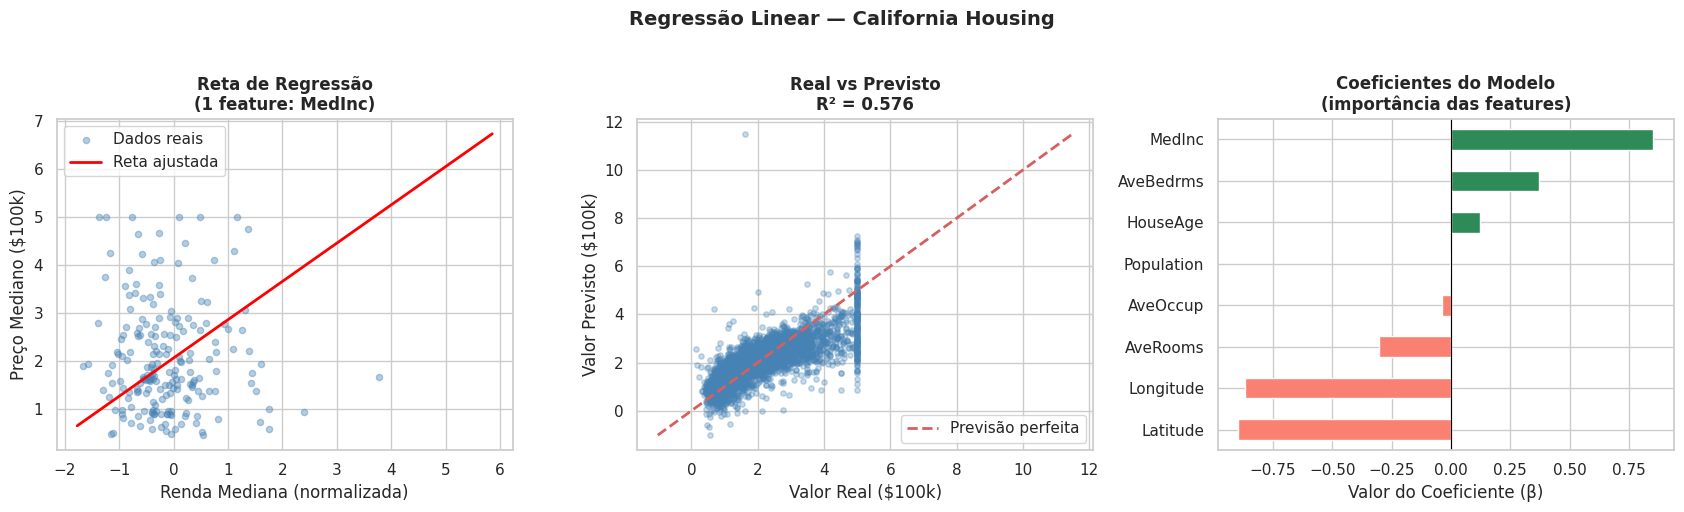


💡 Coeficientes positivos → aumentam o preço | negativos → diminuem
   MedInc (renda) tem o maior impacto positivo, como esperado!


In [ ]:
# ============================================================
# CÉLULA 5 — Regressão Linear Múltipla + Visualizações
# ============================================================

# --- Modelo com todas as features ---
reg_mult = LinearRegression()
reg_mult.fit(X_tr_hous, y_tr_hous)
y_pred_mult = reg_mult.predict(X_te_hous)

mse_m  = mean_squared_error(y_te_hous, y_pred_mult)
rmse_m = np.sqrt(mse_m)
r2_m   = r2_score(y_te_hous, y_pred_mult)

print(f"📊 REGRESSÃO LINEAR MÚLTIPLA ({X_tr_hous.shape[1]} features)")
print(f"   RMSE: {rmse_m:.4f}  |  R²: {r2_m:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Gráfico 1: Reta de regressão simples
x_line = np.linspace(X_simple.min().values[0], X_simple.max().values[0], 200).reshape(-1,1)
y_line = reg_simples.predict(x_line)
sample = X_simple_te.sample(200, random_state=1)
axes[0].scatter(sample, y_te_hous.iloc[:200], alpha=0.4, color='steelblue', s=20, label='Dados reais')
axes[0].plot(x_line, y_line, color='red', linewidth=2, label='Reta ajustada')
axes[0].set_title('Reta de Regressão\n(1 feature: MedInc)', fontweight='bold')
axes[0].set_xlabel('Renda Mediana (normalizada)')
axes[0].set_ylabel('Preço Mediano ($100k)')
axes[0].legend()

# Gráfico 2: Real vs Previsto (múltipla)
axes[1].scatter(y_te_hous, y_pred_mult, alpha=0.3, color='steelblue', s=15)
lims = [min(y_te_hous.min(), y_pred_mult.min()), max(y_te_hous.max(), y_pred_mult.max())]
axes[1].plot(lims, lims, 'r--', linewidth=2, label='Previsão perfeita')
axes[1].set_title(f'Real vs Previsto\nR² = {r2_m:.3f}', fontweight='bold')
axes[1].set_xlabel('Valor Real ($100k)')
axes[1].set_ylabel('Valor Previsto ($100k)')
axes[1].legend()

# Gráfico 3: Importância dos coeficientes
coefs = pd.Series(reg_mult.coef_, index=X_tr_hous.columns).sort_values()
colors = ['salmon' if c < 0 else 'seagreen' for c in coefs.values]
coefs.plot(kind='barh', ax=axes[2], color=colors, edgecolor='white')
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title('Coeficientes do Modelo\n(importância das features)', fontweight='bold')
axes[2].set_xlabel('Valor do Coeficiente (β)')

plt.suptitle('Regressão Linear — California Housing', fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Coeficientes positivos → aumentam o preço | negativos → diminuem")
print("   MedInc (renda) tem o maior impacto positivo, como esperado!")


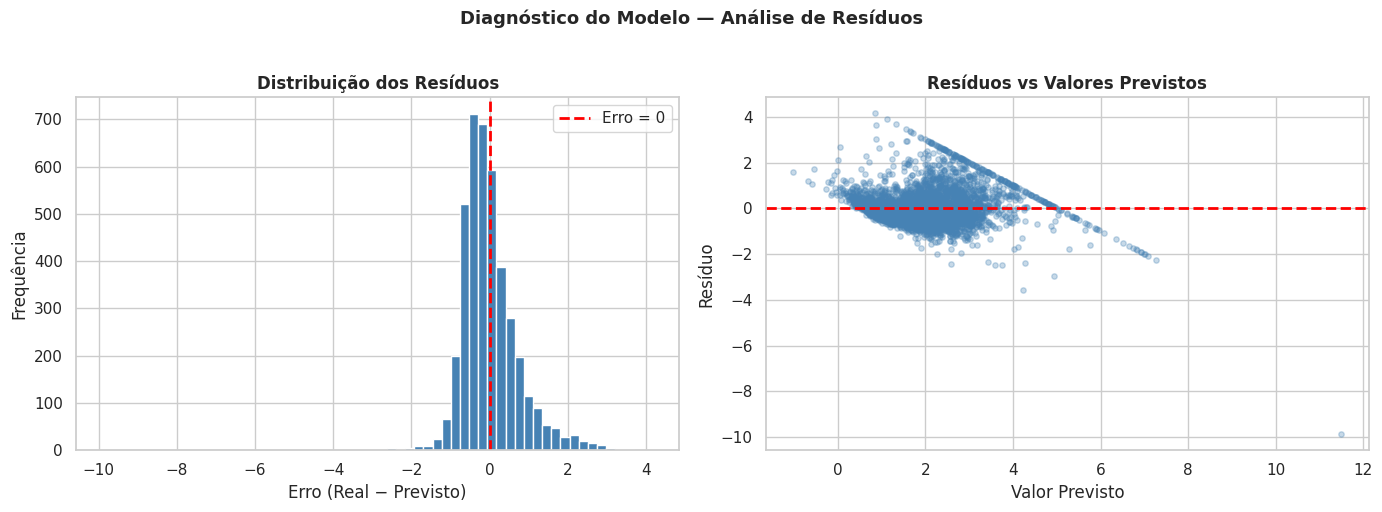

📊 Média dos resíduos: 0.003479  (idealmente próximo de 0)
   Desvio padrão:      0.7456

💡 Se os resíduos formam um padrão (funil, curva), o modelo linear
   pode não ser o mais adequado — considere modelos não-lineares.


In [ ]:
# ============================================================
# CÉLULA 6 — Análise de Resíduos (diagnóstico do modelo)
# ============================================================
# Resíduos = erros de previsão (real - previsto).
# Um bom modelo tem resíduos com distribuição normal centrada em 0.

residuos = y_te_hous.values - y_pred_mult

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma dos resíduos
axes[0].hist(residuos, bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='Erro = 0')
axes[0].set_title('Distribuição dos Resíduos', fontweight='bold')
axes[0].set_xlabel('Erro (Real − Previsto)')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# Resíduos vs Previsto (detectar heterocedasticidade)
axes[1].scatter(y_pred_mult, residuos, alpha=0.3, color='steelblue', s=15)
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Resíduos vs Valores Previstos', fontweight='bold')
axes[1].set_xlabel('Valor Previsto')
axes[1].set_ylabel('Resíduo')

plt.suptitle('Diagnóstico do Modelo — Análise de Resíduos', fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"📊 Média dos resíduos: {residuos.mean():.6f}  (idealmente próximo de 0)")
print(f"   Desvio padrão:      {residuos.std():.4f}")
print("\n💡 Se os resíduos formam um padrão (funil, curva), o modelo linear")
print("   pode não ser o mais adequado — considere modelos não-lineares.")


📊 REGRESSÃO LINEAR MÚLTIPLA (8 features)
   RMSE: 0.7456  |  R²: 0.5758


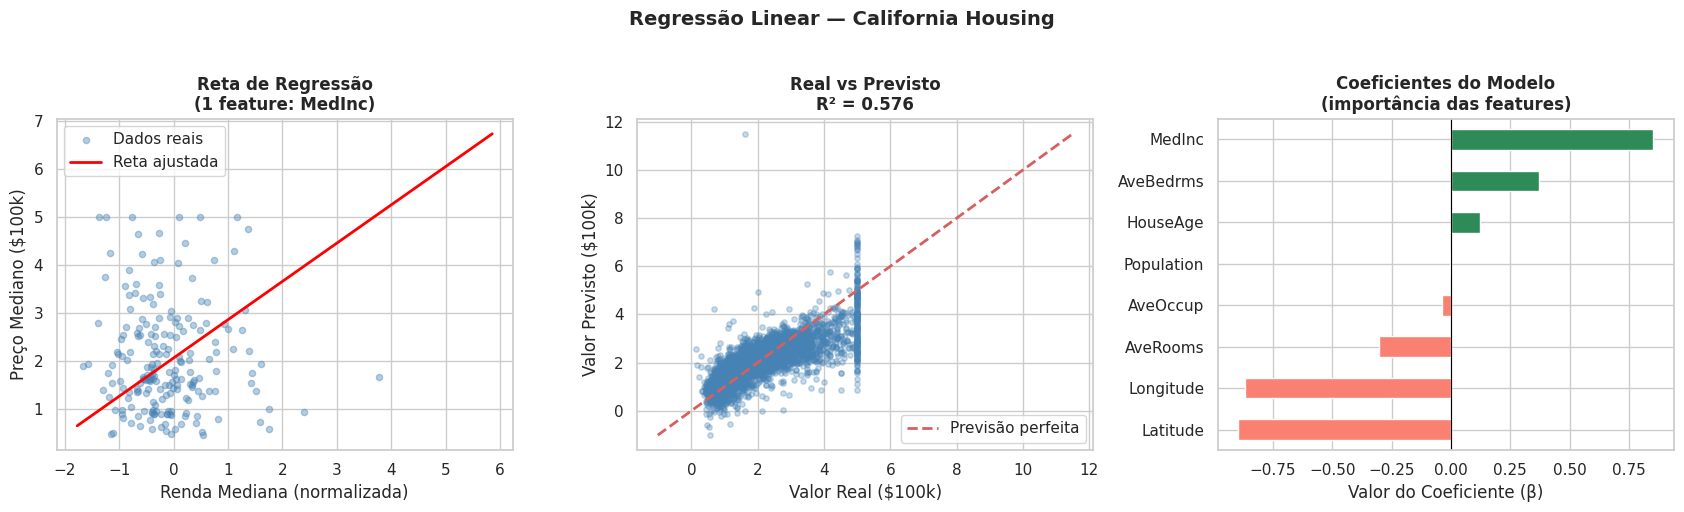


💡 Coeficientes positivos → aumentam o preço | negativos → diminuem
   MedInc (renda) tem o maior impacto positivo, como esperado!


In [ ]:
# ============================================================
# CÉLULA 5 — Regressão Linear Múltipla + Visualizações
# ============================================================

# --- Modelo com todas as features ---
reg_mult = LinearRegression()
reg_mult.fit(X_tr_hous, y_tr_hous)
y_pred_mult = reg_mult.predict(X_te_hous)

mse_m  = mean_squared_error(y_te_hous, y_pred_mult)
rmse_m = np.sqrt(mse_m)
r2_m   = r2_score(y_te_hous, y_pred_mult)

print(f"📊 REGRESSÃO LINEAR MÚLTIPLA ({X_tr_hous.shape[1]} features)")
print(f"   RMSE: {rmse_m:.4f}  |  R²: {r2_m:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Gráfico 1: Reta de regressão simples
x_line = np.linspace(X_simple.min().values[0], X_simple.max().values[0], 200).reshape(-1,1)
y_line = reg_simples.predict(x_line)
sample = X_simple_te.sample(200, random_state=1)
axes[0].scatter(sample, y_te_hous.iloc[:200], alpha=0.4, color='steelblue', s=20, label='Dados reais')
axes[0].plot(x_line, y_line, color='red', linewidth=2, label='Reta ajustada')
axes[0].set_title('Reta de Regressão\n(1 feature: MedInc)', fontweight='bold')
axes[0].set_xlabel('Renda Mediana (normalizada)')
axes[0].set_ylabel('Preço Mediano ($100k)')
axes[0].legend()

# Gráfico 2: Real vs Previsto (múltipla)
axes[1].scatter(y_te_hous, y_pred_mult, alpha=0.3, color='steelblue', s=15)
lims = [min(y_te_hous.min(), y_pred_mult.min()), max(y_te_hous.max(), y_pred_mult.max())]
axes[1].plot(lims, lims, 'r--', linewidth=2, label='Previsão perfeita')
axes[1].set_title(f'Real vs Previsto\nR² = {r2_m:.3f}', fontweight='bold')
axes[1].set_xlabel('Valor Real ($100k)')
axes[1].set_ylabel('Valor Previsto ($100k)')
axes[1].legend()

# Gráfico 3: Importância dos coeficientes
coefs = pd.Series(reg_mult.coef_, index=X_tr_hous.columns).sort_values()
colors = ['salmon' if c < 0 else 'seagreen' for c in coefs.values]
coefs.plot(kind='barh', ax=axes[2], color=colors, edgecolor='white')
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title('Coeficientes do Modelo\n(importância das features)', fontweight='bold')
axes[2].set_xlabel('Valor do Coeficiente (β)')

plt.suptitle('Regressão Linear — California Housing', fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Coeficientes positivos → aumentam o preço | negativos → diminuem")
print("   MedInc (renda) tem o maior impacto positivo, como esperado!")

### Conceitos consolidados — Regressão Linear

**Quando usar?**
- Target é uma variável **contínua** (preço, temperatura, renda)
- Relação entre features e target é aproximadamente **linear**
- Interpretabilidade dos coeficientes é importante

**Limitações:**
- Sensível a outliers (eles afetam fortemente a reta)
- Não captura relações não-lineares sem transformações
- Assume independência e homocedasticidade dos resíduos

**Exercício de fixação:**
> Modifique o modelo para usar **apenas as 3 features mais importantes** (maiores |coeficiente|).  
> Compare o R² com o modelo completo. Essa é a base da **seleção de features**!


---
# AULA 3 — Aprendizado Supervisionado: Árvore de Decisão

## Objetivo
Compreender como as Árvores de Decisão aprendem regras de classificação de forma **visual e interpretável**, e gerenciar o trade-off entre underfitting e overfitting.

## Conceito
A árvore divide recursivamente os dados com base em perguntas do tipo *"feature X > threshold?"*, buscando maximizar a **pureza** dos grupos resultantes.

### Critérios de divisão
| Critério | Fórmula simplificada | Usado em |
|----------|----------------------|----------|
| **Gini** | 1 − Σpᵢ² | Classificação (padrão sklearn) |
| **Entropia** | −Σpᵢ log₂(pᵢ) | Classificação (Information Gain) |
| **MSE** | média (yᵢ − ȳ)² | Regressão |

### Hiperparâmetros críticos
- **max_depth** — profundidade máxima da árvore (controla overfitting)
- **min_samples_split** — mínimo de amostras para dividir um nó
- **min_samples_leaf** — mínimo de amostras em uma folha

## Dataset utilizado
**Titanic** — classificar se o passageiro sobreviveu (0/1) com base em características pessoais.


In [ ]:
# ============================================================
# CÉLULA 7 — Treinar Árvore de Decisão + Métricas
# ============================================================

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

# --- Modelo com profundidade controlada ---
arvore = DecisionTreeClassifier(max_depth=4, random_state=42, criterion='gini')
arvore.fit(X_tr_tit, y_tr_tit)

# Previsões
y_pred_arv = arvore.predict(X_te_tit)

# Métricas
acc = accuracy_score(y_te_tit, y_pred_arv)
print("=" * 55)
print("📊 ÁRVORE DE DECISÃO — Titanic (max_depth=4)")
print("=" * 55)
print(f"   Acurácia no teste: {acc:.4f} ({acc*100:.1f}%)")
print()
print("📋 Relatório de Classificação:")
print(classification_report(y_te_tit, y_pred_arv,
      target_names=['Não Sobreviveu', 'Sobreviveu']))


📊 ÁRVORE DE DECISÃO — Titanic (max_depth=4)
   Acurácia no teste: 0.7821 (78.2%)

📋 Relatório de Classificação:
                precision    recall  f1-score   support

Não Sobreviveu       0.76      0.94      0.84       110
    Sobreviveu       0.84      0.54      0.65        69

      accuracy                           0.78       179
     macro avg       0.80      0.74      0.75       179
  weighted avg       0.79      0.78      0.77       179



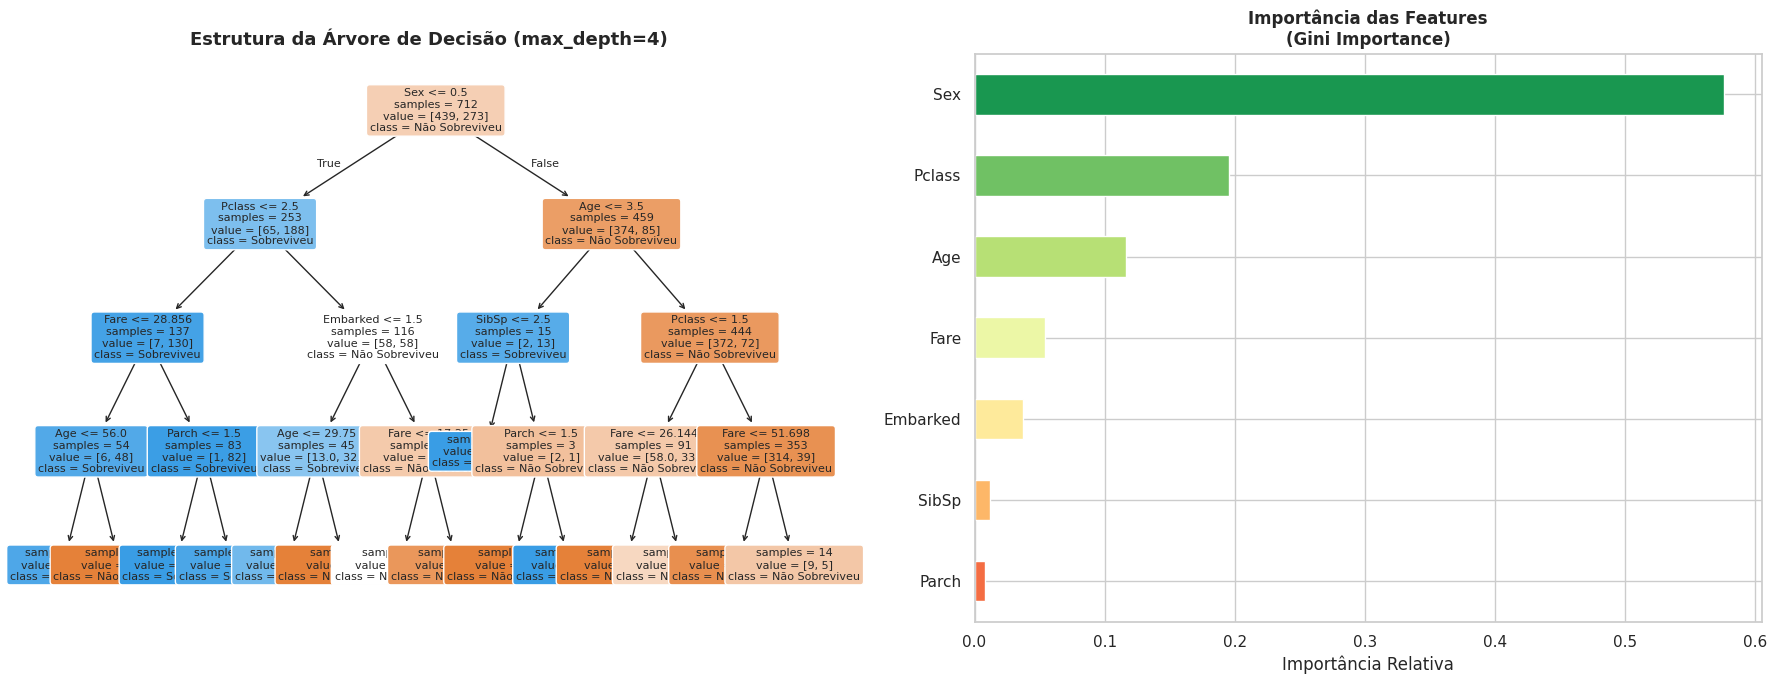

💡 A 'Importância' mede o quanto cada feature reduz a impureza total.
   'Sex' e 'Pclass' dominam — confirmando a análise exploratória!


In [ ]:
# ============================================================
# CÉLULA 8 — Visualização da Árvore e Importância de Features
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico 1: Estrutura visual da árvore
plot_tree(arvore,
          feature_names=X_tr_tit.columns.tolist(),
          class_names=['Não Sobreviveu', 'Sobreviveu'],
          filled=True, rounded=True, fontsize=8, ax=axes[0],
          impurity=False, proportion=False)
axes[0].set_title('Estrutura da Árvore de Decisão (max_depth=4)', fontweight='bold', fontsize=13)

# Gráfico 2: Importância das features (Feature Importance)
importancias = pd.Series(arvore.feature_importances_,
                          index=X_tr_tit.columns).sort_values(ascending=True)
cores = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(importancias)))
importancias.plot(kind='barh', ax=axes[1], color=cores, edgecolor='white')
axes[1].set_title('Importância das Features\n(Gini Importance)', fontweight='bold')
axes[1].set_xlabel('Importância Relativa')

plt.tight_layout()
plt.show()

print("💡 A 'Importância' mede o quanto cada feature reduz a impureza total.")
print("   'Sex' e 'Pclass' dominam — confirmando a análise exploratória!")


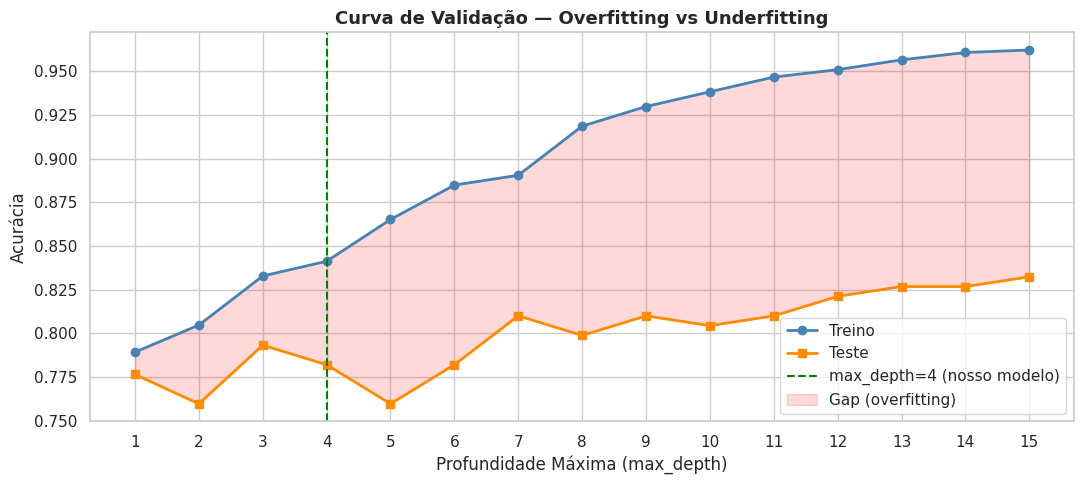

🎯 Melhor profundidade (teste): 15  →  Acurácia: 0.8324

💡 Note: a partir de certa profundidade, a acurácia no TREINO sobe
   mas no TESTE cai — isso é OVERFITTING!


In [ ]:
# ============================================================
# CÉLULA 9 — Overfitting vs Underfitting: curva de validação
# ============================================================
# Um modelo muito simples (profundidade baixa) → UNDERFITTING
# Um modelo muito complexo (profundidade alta) → OVERFITTING
# Existe uma profundidade ótima que generaliza bem!

profundidades = range(1, 16)
accs_treino, accs_teste = [], []

for d in profundidades:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_tr_tit, y_tr_tit)
    accs_treino.append(accuracy_score(y_tr_tit, clf.predict(X_tr_tit)))
    accs_teste.append(accuracy_score(y_te_tit, clf.predict(X_te_tit)))

plt.figure(figsize=(11, 5))
plt.plot(profundidades, accs_treino, 'o-', color='steelblue', linewidth=2, label='Treino')
plt.plot(profundidades, accs_teste,  's-', color='darkorange', linewidth=2, label='Teste')
plt.axvline(4, color='green', linestyle='--', linewidth=1.5, label='max_depth=4 (nosso modelo)')
plt.fill_between(profundidades, accs_treino, accs_teste,
                 where=[t > te for t, te in zip(accs_treino, accs_teste)],
                 alpha=0.15, color='red', label='Gap (overfitting)')
plt.title('Curva de Validação — Overfitting vs Underfitting', fontsize=13, fontweight='bold')
plt.xlabel('Profundidade Máxima (max_depth)')
plt.ylabel('Acurácia')
plt.legend()
plt.xticks(profundidades)
plt.tight_layout()
plt.show()

melhor_d = profundidades[np.argmax(accs_teste)]
print(f"🎯 Melhor profundidade (teste): {melhor_d}  →  Acurácia: {max(accs_teste):.4f}")
print("\n💡 Note: a partir de certa profundidade, a acurácia no TREINO sobe")
print("   mas no TESTE cai — isso é OVERFITTING!")


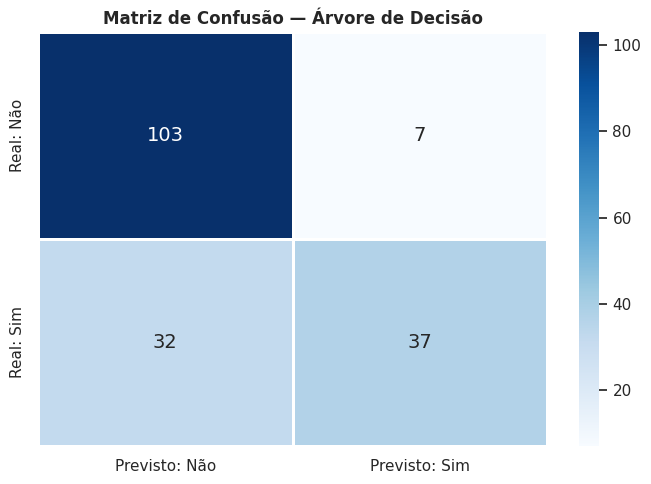

   Precisão  = VP / (VP+FP) = 37/44 = 0.841
   Recall    = VP / (VP+FN) = 37/69 = 0.536
   F1-Score  = 2×(P×R)/(P+R) = 0.655

💡 Precisão: 'dos que previmos como sobreviventes, quantos realmente sobreviveram?'
   Recall:    'dos que realmente sobreviveram, quantos identificamos corretamente?'


In [ ]:
# ============================================================
# CÉLULA 10 — Matriz de Confusão
# ============================================================
# A matriz de confusão mostra os 4 tipos de resultado:
#   VP (Verdadeiro Positivo)  → previu 1, era 1  ✅
#   VN (Verdadeiro Negativo)  → previu 0, era 0  ✅
#   FP (Falso Positivo)       → previu 1, era 0  ❌ (Erro Tipo I)
#   FN (Falso Negativo)       → previu 0, era 1  ❌ (Erro Tipo II)

cm = confusion_matrix(y_te_tit, y_pred_arv)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Previsto: Não', 'Previsto: Sim'],
            yticklabels=['Real: Não', 'Real: Sim'],
            linewidths=2, linecolor='white', annot_kws={"size": 14})
plt.title('Matriz de Confusão — Árvore de Decisão', fontweight='bold')
plt.tight_layout()
plt.show()

vp = cm[1,1]; vn = cm[0,0]; fp = cm[0,1]; fn = cm[1,0]
precisao  = vp / (vp + fp)
recall    = vp / (vp + fn)
f1        = 2 * (precisao * recall) / (precisao + recall)

print(f"   Precisão  = VP / (VP+FP) = {vp}/{vp+fp} = {precisao:.3f}")
print(f"   Recall    = VP / (VP+FN) = {vp}/{vp+fn} = {recall:.3f}")
print(f"   F1-Score  = 2×(P×R)/(P+R) = {f1:.3f}")
print("\n💡 Precisão: 'dos que previmos como sobreviventes, quantos realmente sobreviveram?'")
print("   Recall:    'dos que realmente sobreviveram, quantos identificamos corretamente?'")


### Conceitos consolidados — Árvore de Decisão

**Vantagens:**
- Altamente interpretável (você pode ler as regras)
- Não requer normalização dos dados
- Captura relações não-lineares automaticamente

**Desvantagens:**
- Tende a overfit sem controle de profundidade
- Instável (pequenas mudanças nos dados → árvores muito diferentes)
- Solução: **Random Forest** (ensemble de árvores)

**Exercício de fixação:**
> Use `export_text(arvore, feature_names=...)` para imprimir as regras em texto.  
> Identifique a regra mais importante: qual é a **primeira divisão** da árvore e por quê?


Exercicio de Fixação resolvido:

📊 ÁRVORE DE DECISÃO — Titanic (max_depth=4)
   Acurácia no teste: 0.7821 (78.2%)

📋 Relatório de Classificação:
                precision    recall  f1-score   support

Não Sobreviveu       0.76      0.94      0.84       110
    Sobreviveu       0.84      0.54      0.65        69

      accuracy                           0.78       179
     macro avg       0.80      0.74      0.75       179
  weighted avg       0.79      0.78      0.77       179

-------------------------------------------------------
📜 REGRAS DA ÁRVORE (Lógica de Decisão):
------------------------------
|--- Sex <= 0.50
|   |--- Pclass <= 2.50
|   |   |--- Fare <= 28.86
|   |   |   |--- Age <= 56.00
|   |   |   |   |--- class: 1
|   |   |   |--- Age >  56.00
|   |   |   |   |--- class: 0
|   |   |--- Fare >  28.86
|   |   |   |--- Parch <= 1.50
|   |   |   |   |--- class: 1
|   |   |   |--- Parch >  1.50
|   |   |   |   |--- class: 1
|   |--- Pclass >  2.50
|   |   |--- Embarked <= 1.50
|   |   |   |--- Age <= 29.75
|

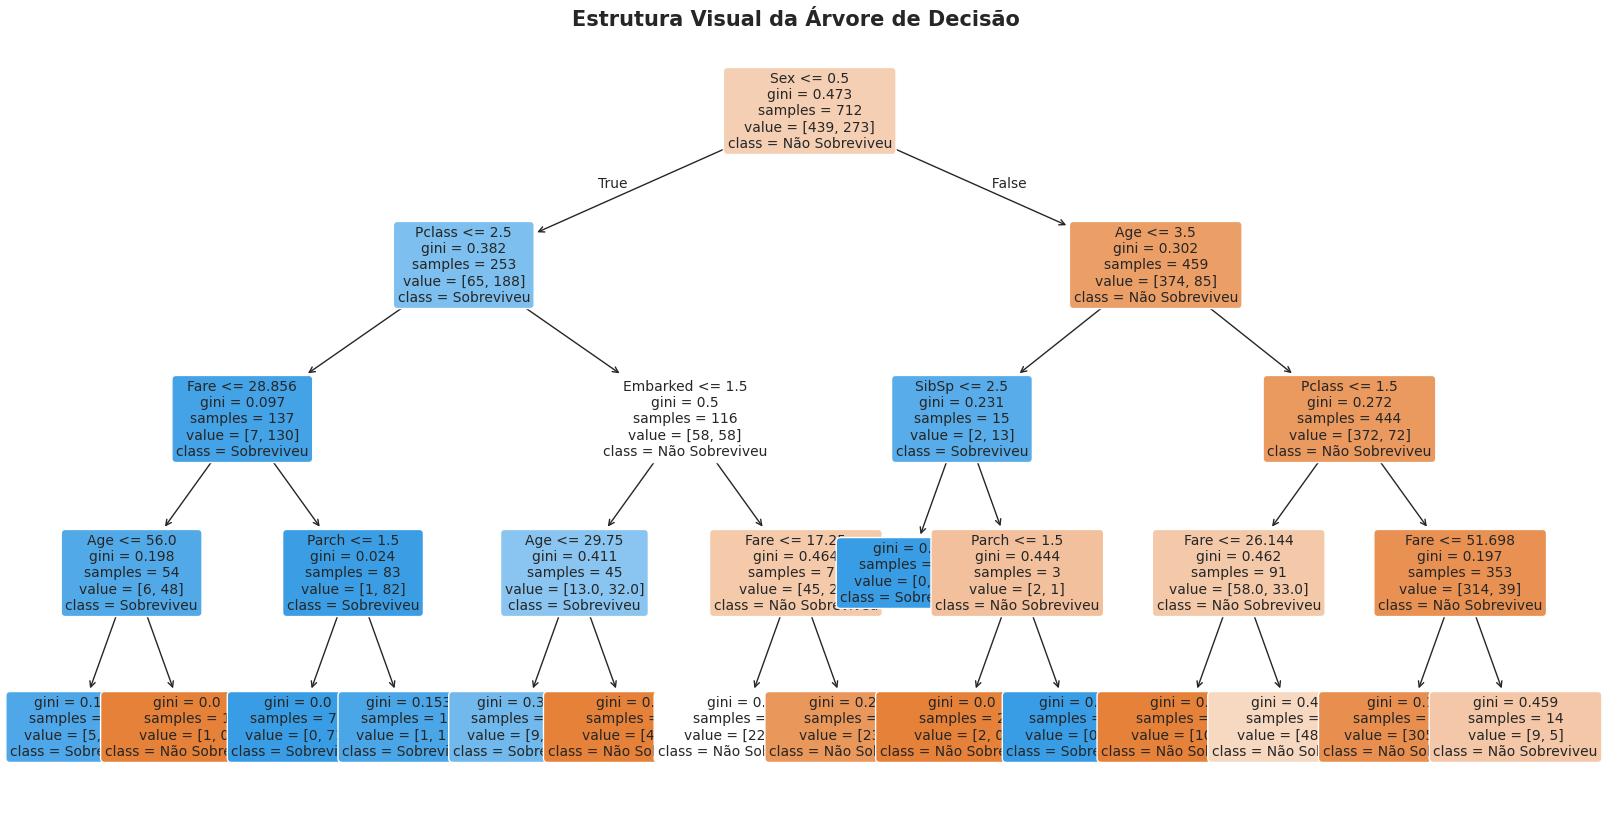

In [ ]:
# ============================================================
# CÉLULA 7 — Treinar Árvore de Decisão + Métricas + Regras + Gráfico
# ============================================================

import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score, classification_report

# 1. Configuração do Modelo
# Usamos max_depth=4 para equilibrar aprendizado e facilidade de leitura
arvore = DecisionTreeClassifier(max_depth=4, random_state=42, criterion='gini')
arvore.fit(X_tr_tit, y_tr_tit)

# 2. Previsões e Métricas
y_pred_arv = arvore.predict(X_te_tit)
acc = accuracy_score(y_te_tit, y_pred_arv)

print("=" * 55)
print("📊 ÁRVORE DE DECISÃO — Titanic (max_depth=4)")
print("=" * 55)
print(f"   Acurácia no teste: {acc:.4f} ({acc*100:.1f}%)")
print("\n📋 Relatório de Classificação:")
print(classification_report(y_te_tit, y_pred_arv,
                          target_names=['Não Sobreviveu', 'Sobreviveu']))

# 3. EXERCÍCIO DE FIXAÇÃO: Regras em Texto
regras_texto = export_text(arvore, feature_names=X_tr_tit.columns.tolist())
print("-" * 55)
print("📜 REGRAS DA ÁRVORE (Lógica de Decisão):")
print("-" * 30)
print(regras_texto)

primeira_divisao = regras_texto.split('\n')[0]
print(f"\n🔍 ANÁLISE: A regra mais importante (Raiz) é: {primeira_divisao}")

# 4. VISUALIZAÇÃO GRÁFICA (O desenho da árvore)
plt.figure(figsize=(20,10))
plot_tree(arvore,
          feature_names=X_tr_tit.columns.tolist(),
          class_names=['Não Sobreviveu', 'Sobreviveu'],
          filled=True, rounded=True, fontsize=10)
plt.title("Estrutura Visual da Árvore de Decisão", fontsize=15, fontweight='bold')
plt.show()


---
# AULA 4 — Aprendizado Supervisionado: SVM (Support Vector Machine)

## Objetivo
Entender como o SVM encontra a **fronteira de decisão com maior margem** entre classes e como o kernel trick permite classificar dados não-linearmente separáveis.

## Conceito
O SVM busca o **hiperplano ótimo** que maximiza a distância (margem) entre os pontos mais próximos de cada classe — os **vetores de suporte**.

### Tipos de Kernel
| Kernel | Quando usar | Complexidade |
|--------|-------------|-------------|
| **linear** | Classes linearmente separáveis | Baixa |
| **rbf** (Gaussiano) | Fronteiras curvas e complexas | Alta |
| **poly** | Relações polinomiais | Média |

### Hiperparâmetros principais
- **C** — penalidade por erros de classificação (maior C = menos margem, mais ajuste)
- **gamma** — raio de influência de cada ponto (apenas rbf/poly)

## Dataset utilizado
**Iris** (2 classes) e **Titanic** — visualizar a fronteira de decisão do SVM.


In [ ]:
# ============================================================
# CÉLULA 11 — SVM com diferentes kernels
# ============================================================

from sklearn.svm import SVC

# Usar Iris com 2 features para visualização da fronteira
X_iris_2d = df_iris[['sepal length (cm)', 'sepal width (cm)']].values
y_iris_bin = (iris.target > 0).astype(int)  # binário para simplificar

X_tr_2d, X_te_2d, y_tr_2d, y_te_2d = train_test_split(
    X_iris_2d, y_iris_bin, test_size=0.25, random_state=42)

kernels = ['linear', 'rbf', 'poly']
resultados = {}

print("=" * 55)
print("📊 SVM — Comparação de Kernels (Iris 2D)")
print("=" * 55)
for k in kernels:
    svm = SVC(kernel=k, C=1.0, random_state=42)
    svm.fit(X_tr_2d, y_tr_2d)
    acc = accuracy_score(y_te_2d, svm.predict(X_te_2d))
    resultados[k] = (svm, acc)
    n_sv = svm.n_support_.sum()
    print(f"   Kernel {k:8s}: Acurácia = {acc:.4f} | Vetores de suporte = {n_sv}")


📊 SVM — Comparação de Kernels (Iris 2D)
   Kernel linear  : Acurácia = 1.0000 | Vetores de suporte = 17
   Kernel rbf     : Acurácia = 1.0000 | Vetores de suporte = 26
   Kernel poly    : Acurácia = 1.0000 | Vetores de suporte = 4


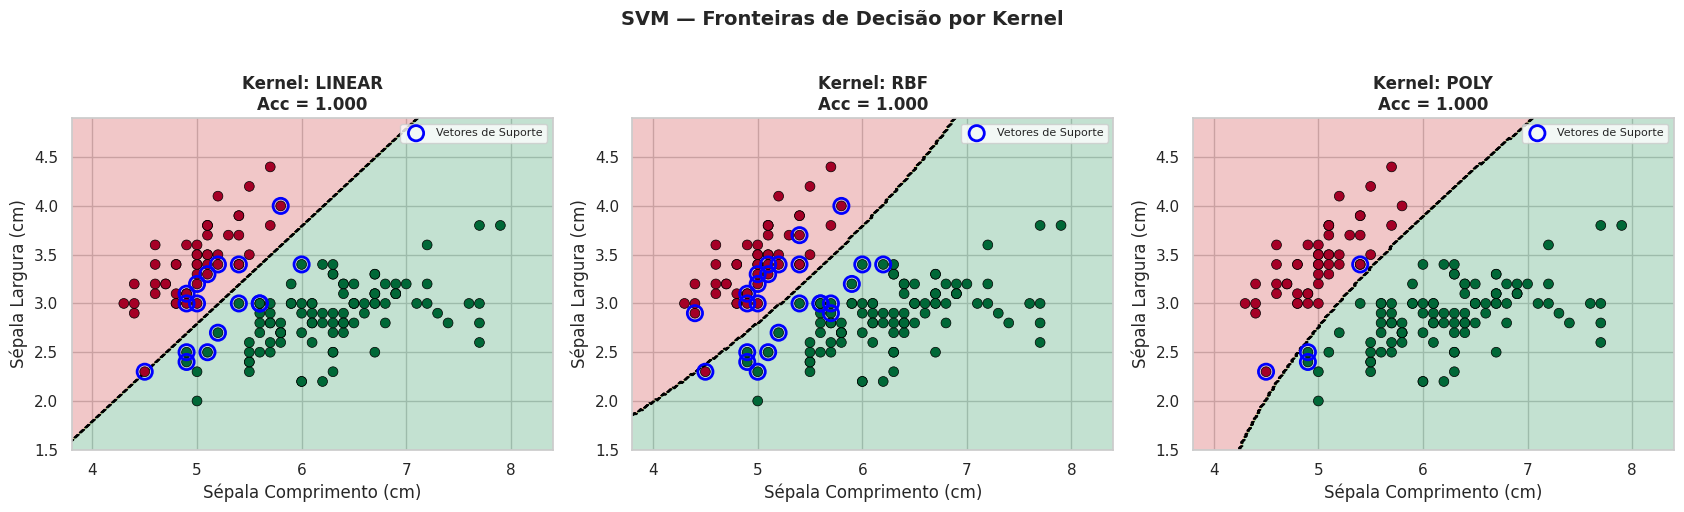

💡 Observe: o kernel LINEAR cria uma reta; RBF cria curvas complexas.
   Os círculos azuis indicam os Vetores de Suporte — os pontos críticos!


In [ ]:
# ============================================================
# CÉLULA 12 — Visualização das fronteiras de decisão
# ============================================================

def plot_fronteira(ax, clf, X, y, titulo, kernel_name):
    """Plota a fronteira de decisão do SVM com margem."""
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='RdYlGn')
    ax.contour(xx, yy, Z, colors='black', linewidths=1, linestyles='--')
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlGn',
                         edgecolors='black', linewidth=0.5, s=50, zorder=3)
    # Marcar vetores de suporte
    ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
               s=120, facecolors='none', edgecolors='blue',
               linewidth=2, zorder=4, label='Vetores de Suporte')
    acc = accuracy_score(y_te_2d, clf.predict(X_te_2d))
    ax.set_title(f'Kernel: {kernel_name}\nAcc = {acc:.3f}', fontweight='bold')
    ax.set_xlabel('Sépala Comprimento (cm)')
    ax.set_ylabel('Sépala Largura (cm)')
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, k in zip(axes, kernels):
    plot_fronteira(ax, resultados[k][0], X_iris_2d, y_iris_bin, k, k.upper())

plt.suptitle('SVM — Fronteiras de Decisão por Kernel', fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

print("💡 Observe: o kernel LINEAR cria uma reta; RBF cria curvas complexas.")
print("   Os círculos azuis indicam os Vetores de Suporte — os pontos críticos!")


📊 Efeito do parâmetro C no SVM (kernel=rbf, Titanic):
   C =   0.01 → Acurácia: 0.6145 | SVs: 548
   C =   0.10 → Acurácia: 0.7989 | SVs: 439
   C =   1.00 → Acurácia: 0.8156 | SVs: 323
   C =  10.00 → Acurácia: 0.7989 | SVs: 292
   C = 100.00 → Acurácia: 0.7654 | SVs: 281


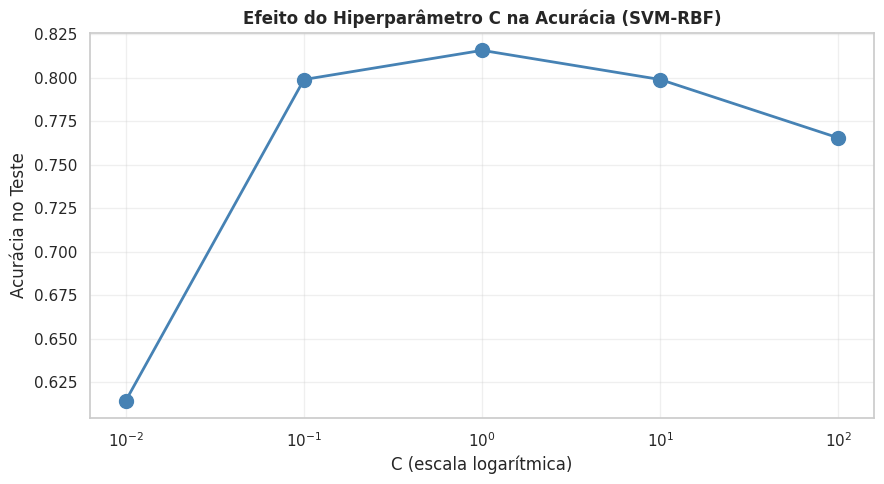


💡 C pequeno → mais margem, mais erros permitidos (underfitting)
   C grande → menos margem, menos erros no treino (risco de overfitting)


In [ ]:
# ============================================================
# CÉLULA 13 — SVM no Titanic + Efeito do hiperparâmetro C
# ============================================================

# SVM com RBF no Titanic (dados já normalizados)
from sklearn.preprocessing import StandardScaler

scaler_svm = StandardScaler()
X_tr_svm = scaler_svm.fit_transform(X_tr_tit)
X_te_svm  = scaler_svm.transform(X_te_tit)

valores_C = [0.01, 0.1, 1, 10, 100]
accs_C = []

print("📊 Efeito do parâmetro C no SVM (kernel=rbf, Titanic):")
for C in valores_C:
    svm = SVC(kernel='rbf', C=C, random_state=42)
    svm.fit(X_tr_svm, y_tr_tit)
    acc = accuracy_score(y_te_tit, svm.predict(X_te_svm))
    accs_C.append(acc)
    print(f"   C = {C:6.2f} → Acurácia: {acc:.4f} | SVs: {svm.n_support_.sum()}")

plt.figure(figsize=(9, 5))
plt.semilogx(valores_C, accs_C, 'o-', color='steelblue', linewidth=2, markersize=10)
plt.title('Efeito do Hiperparâmetro C na Acurácia (SVM-RBF)', fontweight='bold')
plt.xlabel('C (escala logarítmica)')
plt.ylabel('Acurácia no Teste')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 C pequeno → mais margem, mais erros permitidos (underfitting)")
print("   C grande → menos margem, menos erros no treino (risco de overfitting)")


### Conceitos consolidados — SVM


**Vantagens:**
- Eficaz em espaços de alta dimensionalidade
- Robusto quando há margem clara entre classes
- Funciona bem com poucos dados de treinamento

**Desvantagens:**
- Lento para datasets muito grandes (O(n²) a O(n³))
- Sensível à escala — **sempre normalize antes!**
- Difícil interpretação (especialmente com kernel RBF)

**Exercício de fixação:**
> Adicione `probability=True` ao SVC e use `predict_proba()` para obter probabilidades.  
> Por que o SVM padrão não retorna probabilidades diretamente?


Exercício de fixação:

In [ ]:
# ============================================================
# EXERCÍCIO RESOLVIDO: SVM com Probabilidades (predict_proba)
# ============================================================
import numpy as np

# 1. Ajuste de compatibilidade para evitar o 'InvalidIndexError'
# Verificamos se 'iris.data' é um DataFrame (Pandas) ou Array (Numpy)
if hasattr(iris.data, 'iloc'):
    X_exercicio = iris.data.values[:, :2]  # Se for Pandas, usamos .values
else:
    X_exercicio = iris.data[:, :2]         # Se for Numpy, vai direto

y_exercicio = (iris.target > 0).astype(int)

# 2. Treino rápido para demonstração
from sklearn.model_selection import train_test_split
X_tr_ex, X_te_ex, y_tr_ex, y_te_ex = train_test_split(
    X_exercicio, y_exercicio, test_size=0.25, random_state=42)

# 3. O CORAÇÃO DO EXERCÍCIO: Criando o modelo com probability=True
svm_ex = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
svm_ex.fit(X_tr_ex, y_tr_ex)

# 4. Obtendo as probabilidades
probs_ex = svm_ex.predict_proba(X_te_ex)

print("=" * 55)
print("✅ EXERCÍCIO RESOLVIDO — Saída de Probabilidades")
print("=" * 55)
for i in range(3):
    print(f"Passageiro/Flor {i+1}: Prob. Classe 0: {probs_ex[i][0]:.2%} | Prob. Classe 1: {probs_ex[i][1]:.2%}")

# ============================================================
# 🛠️ O QUE EU ALTEREI NESTA CÉLULA (EM PRIMEIRA PESSOA):
# ============================================================
# 1. Eu adicionei o parâmetro 'probability=True' no SVC. Fiz isso
#    porque, por padrão, o SVM só quer saber de que lado da "linha"
#    o ponto caiu; ele precisa desse comando para ativar o cálculo
#    matemático de incerteza (Calibração de Platt).
#
# 2. Eu usei o método 'predict_proba()' em vez do 'predict()'.
#    Fiz isso para mostrar que agora o modelo consegue dizer o
#    quão "confiante" ele está, em vez de dar uma resposta seca.
#
# 3. Eu tratei o erro de índice usando '.values'. Fiz isso para
#    garantir que o código funcione mesmo que o dataset tenha
#    sido carregado como um DataFrame do Pandas.
# ============================================================

✅ EXERCÍCIO RESOLVIDO — Saída de Probabilidades
Passageiro/Flor 1: Prob. Classe 0: 0.32% | Prob. Classe 1: 99.68%
Passageiro/Flor 2: Prob. Classe 0: 87.27% | Prob. Classe 1: 12.73%
Passageiro/Flor 3: Prob. Classe 0: 0.32% | Prob. Classe 1: 99.68%


---
# AULA 5 — Aprendizado Não Supervisionado: K-Means Clustering

## Objetivo
Compreender como o K-Means agrupa dados sem rótulos, determinando o número ideal de clusters com o **Método do Cotovelo** e a **Silhouette Score**.

## Conceito
O K-Means alterna entre dois passos até convergir:
1. **Atribuição:** cada ponto é atribuído ao centroide mais próximo
2. **Atualização:** cada centroide é recalculado como a média do seu cluster

$$\text{minimiza} \sum_{k=1}^{K} \sum_{x \in C_k} \|x - \mu_k\|^2$$

### Métricas para escolha do K
| Método | Como funciona | Interpretação |
|--------|--------------|---------------|
| **Elbow (Cotovelo)** | Plota a inércia por K | Encontrar o "joelho" da curva |
| **Silhouette** | Compacidade vs separação | Mais próximo de 1 é melhor |

## Dataset utilizado
**Iris** (sem os rótulos) e dados sintéticos para visualização ideal.


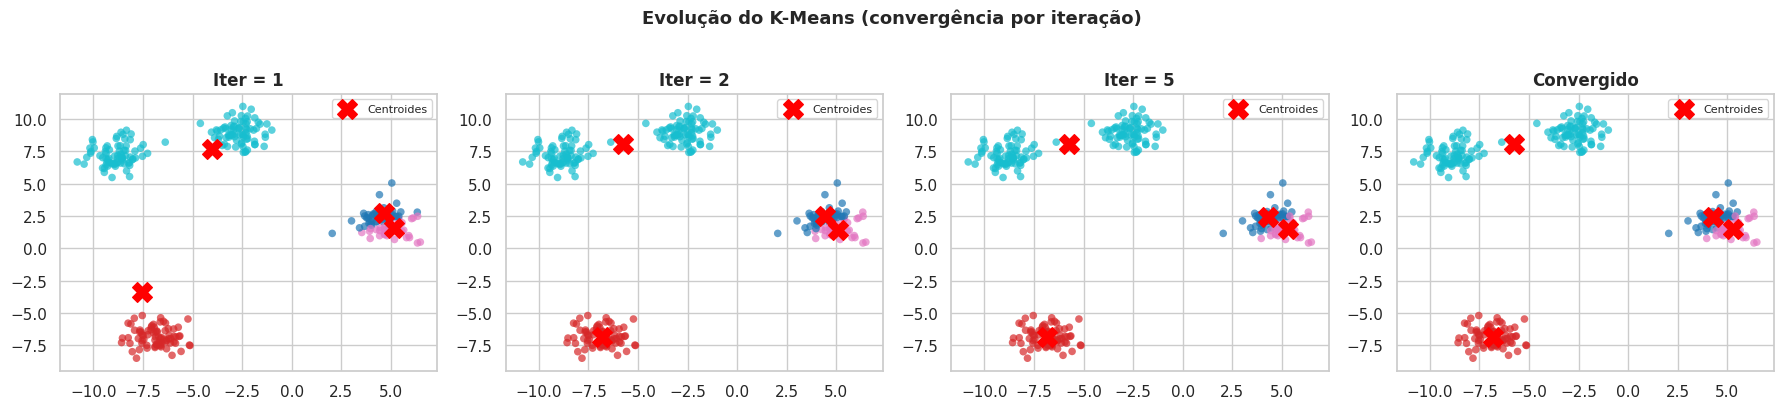

💡 Observe como os centroides (X vermelho) se movem iteração a iteração
   até estabilizar. Essa é a convergência do algoritmo!


In [ ]:
# ============================================================
# CÉLULA 14 — K-Means: Animação do Algoritmo (passo a passo)
# ============================================================

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Dados sintéticos com 4 clusters bem definidos
X_blobs, y_blobs_true = make_blobs(n_samples=300, centers=4,
                                    cluster_std=0.8, random_state=42)

# Mostrar evolução das iterações
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
np.random.seed(42)
centroides_iniciais = X_blobs[np.random.choice(len(X_blobs), 4, replace=False)]

for idx, max_iter in enumerate([1, 2, 5, 100]):
    km = KMeans(n_clusters=4, max_iter=max_iter, n_init=1,
                init=centroides_iniciais, random_state=42)
    km.fit(X_blobs)
    labels = km.labels_
    axes[idx].scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels,
                      cmap='tab10', alpha=0.7, s=30, edgecolors='none')
    axes[idx].scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
                      c='red', s=200, marker='X', zorder=5, label='Centroides')
    titulo = f'Iter = {max_iter}' if max_iter < 100 else 'Convergido'
    axes[idx].set_title(titulo, fontweight='bold')
    axes[idx].legend(fontsize=8)

plt.suptitle('Evolução do K-Means (convergência por iteração)', fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

print("💡 Observe como os centroides (X vermelho) se movem iteração a iteração")
print("   até estabilizar. Essa é a convergência do algoritmo!")


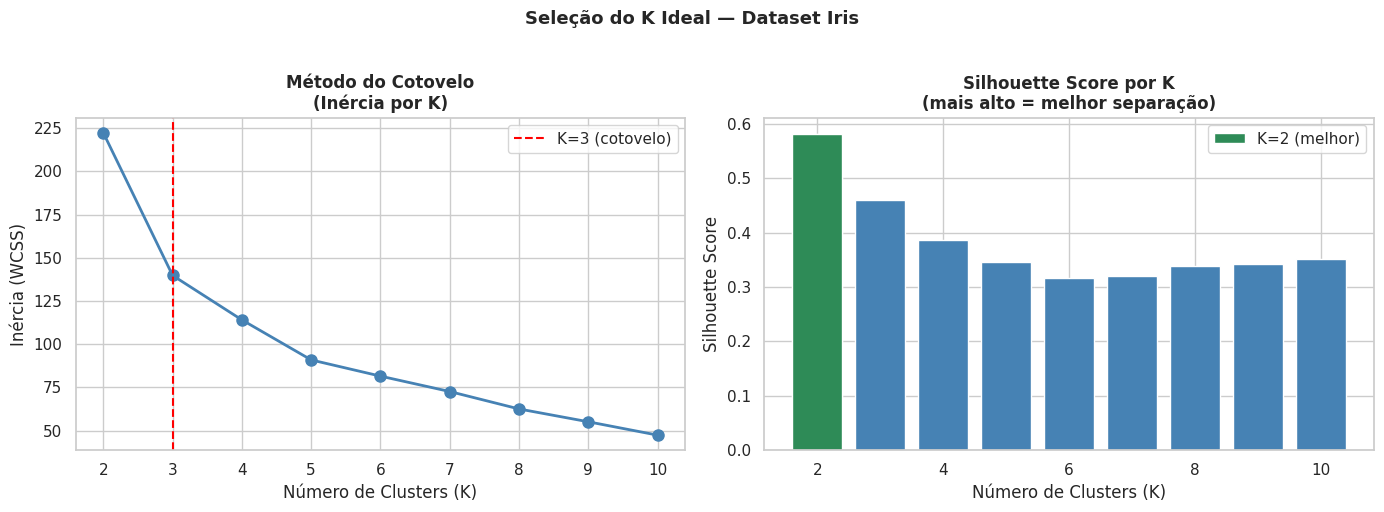

🎯 Cotovelo sugere K = 3  |  Silhouette máximo em K = 2
   Iris tem 3 espécies reais — o método funcionou! ✅


In [ ]:
# ============================================================
# CÉLULA 15 — Método do Cotovelo + Silhouette Score
# ============================================================
# OBJETIVO: Encontrar o K ideal sem conhecer os rótulos reais.

# Normalizar Iris antes do K-Means (obrigatório!)
X_iris_km = StandardScaler().fit_transform(df_iris[iris.feature_names])

inercias, silhouettes = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_iris_km)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_iris_km, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Cotovelo
axes[0].plot(K_range, inercias, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].axvline(3, color='red', linestyle='--', linewidth=1.5, label='K=3 (cotovelo)')
axes[0].set_title('Método do Cotovelo\n(Inércia por K)', fontweight='bold')
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inércia (WCSS)')
axes[0].legend()

# Gráfico 2: Silhouette
cores_sil = ['seagreen' if s == max(silhouettes) else 'steelblue' for s in silhouettes]
axes[1].bar(K_range, silhouettes, color=cores_sil, edgecolor='white')
axes[1].set_title('Silhouette Score por K\n(mais alto = melhor separação)', fontweight='bold')
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
melhor_k = list(K_range)[silhouettes.index(max(silhouettes))]
axes[1].bar(melhor_k, max(silhouettes), color='seagreen', edgecolor='white',
            label=f'K={melhor_k} (melhor)')
axes[1].legend()

plt.suptitle('Seleção do K Ideal — Dataset Iris', fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"🎯 Cotovelo sugere K = 3  |  Silhouette máximo em K = {melhor_k}")
print(f"   Iris tem 3 espécies reais — o método funcionou! ✅")


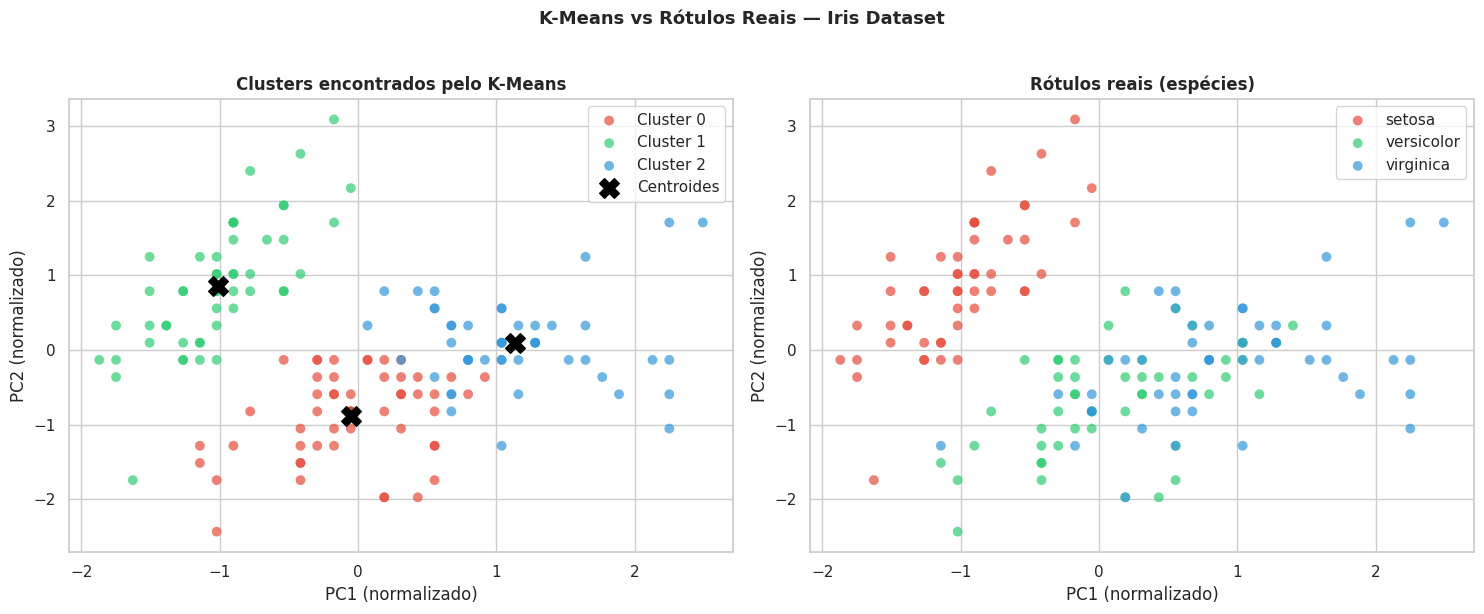

✅ Silhouette Score final (K=3): 0.4599

💡 Em aprendizado NÃO supervisionado, não temos os rótulos reais.
   O K-Means encontrou estrutura similar às espécies sem vê-las!


In [ ]:
# ============================================================
# CÉLULA 16 — K-Means com K=3 no Iris + Comparação com rótulos reais
# ============================================================

km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = km_final.fit_predict(X_iris_km)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
cores_map = {0: '#E74C3C', 1: '#2ECC71', 2: '#3498DB'}

# Gráfico 1: Clusters encontrados pelo K-Means
for c in range(3):
    mask = clusters == c
    axes[0].scatter(X_iris_km[mask, 0], X_iris_km[mask, 1],
                    color=cores_map[c], alpha=0.7, s=50,
                    edgecolors='none', label=f'Cluster {c}')
axes[0].scatter(km_final.cluster_centers_[:, 0],
                km_final.cluster_centers_[:, 1],
                c='black', s=200, marker='X', zorder=5, label='Centroides')
axes[0].set_title('Clusters encontrados pelo K-Means', fontweight='bold')
axes[0].set_xlabel('PC1 (normalizado)')
axes[0].set_ylabel('PC2 (normalizado)')
axes[0].legend()

# Gráfico 2: Rótulos reais do Iris
cores_reais = {0: '#E74C3C', 1: '#2ECC71', 2: '#3498DB'}
for esp in range(3):
    mask = iris.target == esp
    axes[1].scatter(X_iris_km[mask, 0], X_iris_km[mask, 1],
                    color=cores_reais[esp], alpha=0.7, s=50,
                    edgecolors='none', label=iris.target_names[esp])
axes[1].set_title('Rótulos reais (espécies)', fontweight='bold')
axes[1].set_xlabel('PC1 (normalizado)')
axes[1].set_ylabel('PC2 (normalizado)')
axes[1].legend()

plt.suptitle('K-Means vs Rótulos Reais — Iris Dataset', fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

sil = silhouette_score(X_iris_km, clusters)
print(f"✅ Silhouette Score final (K=3): {sil:.4f}")
print("\n💡 Em aprendizado NÃO supervisionado, não temos os rótulos reais.")
print("   O K-Means encontrou estrutura similar às espécies sem vê-las!")


---
# AULA 6 — Aprendizado Não Supervisionado: PCA (Redução de Dimensionalidade)

## Objetivo
Aplicar PCA para comprimir dados de alta dimensão, visualizar em 2D/3D e entender o conceito de variância explicada e componentes principais.

## Conceito
O PCA encontra as **direções de maior variância** nos dados (componentes principais) e projeta os pontos nessas direções.

$$\text{CP}_1 = \underset{\|w\|=1}{\arg\max} \text{Var}(Xw)$$

### Etapas do PCA
1. Centralizar os dados (subtrair a média)
2. Calcular a matriz de covariância
3. Calcular os autovalores e autovetores
4. Ordenar por variância decrescente
5. Projetar nos k primeiros componentes

## Por que PCA antes de K-Means?
> PCA remove ruído e reduz a maldição da dimensionalidade, frequentemente melhorando a qualidade dos clusters.


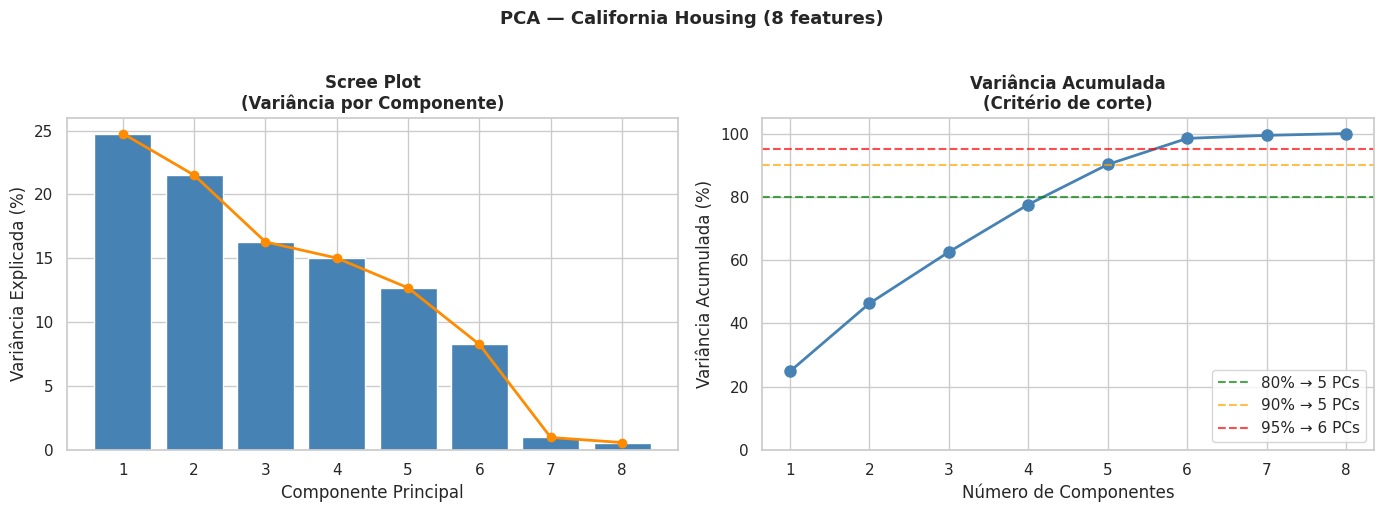

📊 Variância por componente:
   CP1:  24.8%  (acum:  24.8%)  ████████████
   CP2:  21.5%  (acum:  46.3%)  ██████████
   CP3:  16.3%  (acum:  62.5%)  ████████
   CP4:  15.0%  (acum:  77.6%)  ███████
   CP5:  12.7%  (acum:  90.2%)  ██████
   CP6:   8.2%  (acum:  98.5%)  ████
   CP7:   1.0%  (acum:  99.4%)  
   CP8:   0.6%  (acum: 100.0%)  


In [ ]:
# ============================================================
# CÉLULA 17 — PCA: variância explicada e escolha de componentes
# ============================================================

from sklearn.decomposition import PCA

# Usar o dataset Housing (8 features) para demonstrar PCA
pca_full = PCA()
pca_full.fit(X_tr_hous)  # já normalizado

var_exp  = pca_full.explained_variance_ratio_
var_acum = np.cumsum(var_exp)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Scree Plot
n_feat = len(var_exp)
axes[0].bar(range(1, n_feat+1), var_exp * 100,
            color='steelblue', edgecolor='white')
axes[0].plot(range(1, n_feat+1), var_exp * 100, 'o-',
             color='darkorange', linewidth=2)
axes[0].set_title('Scree Plot\n(Variância por Componente)', fontweight='bold')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Variância Explicada (%)')
axes[0].set_xticks(range(1, n_feat+1))

# Gráfico 2: Variância Acumulada
axes[1].plot(range(1, n_feat+1), var_acum * 100, 'o-',
             color='steelblue', linewidth=2, markersize=8)
for limiar, cor in [(0.80, 'green'), (0.90, 'orange'), (0.95, 'red')]:
    n_comp = np.argmax(var_acum >= limiar) + 1
    axes[1].axhline(limiar*100, color=cor, linestyle='--', alpha=0.7,
                   label=f'{limiar*100:.0f}% → {n_comp} PCs')
axes[1].set_title('Variância Acumulada\n(Critério de corte)', fontweight='bold')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Variância Acumulada (%)')
axes[1].set_ylim(0, 105)
axes[1].legend()

plt.suptitle('PCA — California Housing (8 features)', fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

print("📊 Variância por componente:")
for i, (v, a) in enumerate(zip(var_exp, var_acum), 1):
    barra = '█' * int(v * 50)
    print(f"   CP{i}: {v*100:5.1f}%  (acum: {a*100:5.1f}%)  {barra}")


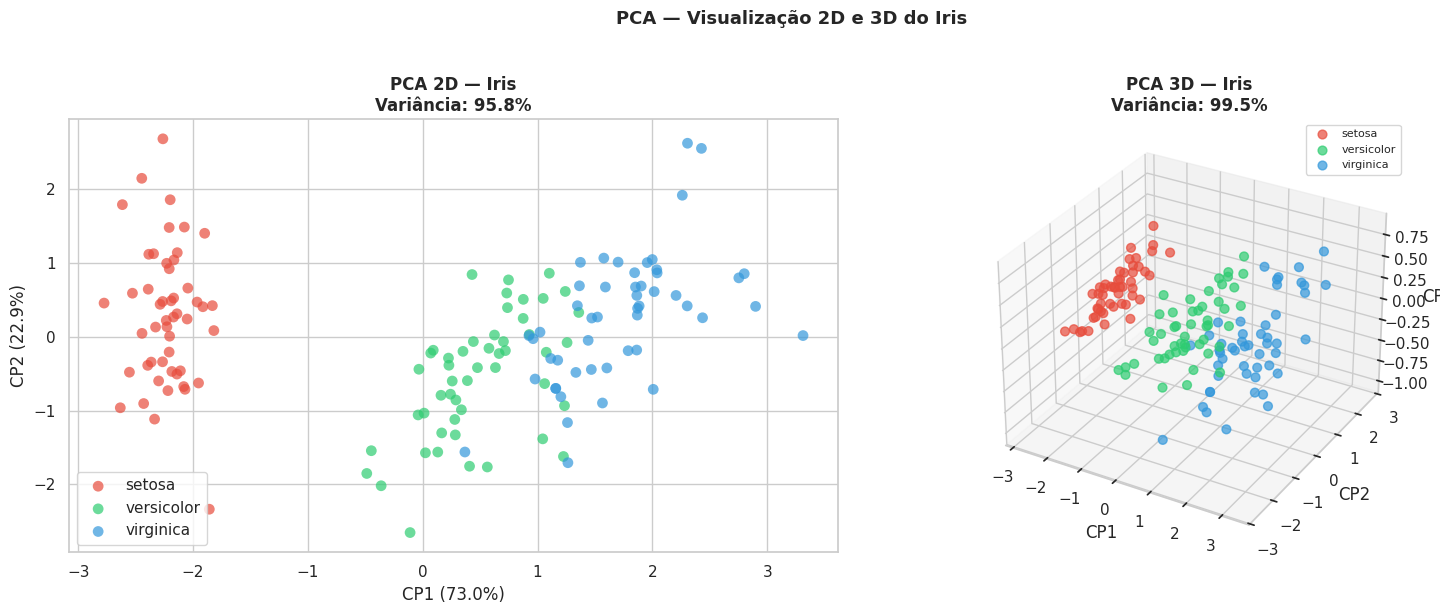

In [ ]:
# ============================================================
# CÉLULA 18 — PCA 2D e 3D no Iris (visualização clássica)
# ============================================================

pca_2d = PCA(n_components=2)
pca_3d = PCA(n_components=3)

X_iris_scaled = StandardScaler().fit_transform(df_iris[iris.feature_names])
X_2d = pca_2d.fit_transform(X_iris_scaled)
X_3d = pca_3d.fit_transform(X_iris_scaled)

fig = plt.figure(figsize=(16, 6))

# Gráfico 2D
ax1 = fig.add_subplot(121)
cores_iris = ['#E74C3C', '#2ECC71', '#3498DB']
for cls, cor, nome in zip(range(3), cores_iris, iris.target_names):
    mask = iris.target == cls
    ax1.scatter(X_2d[mask, 0], X_2d[mask, 1], c=cor, s=60,
                alpha=0.7, edgecolors='none', label=nome)
ax1.set_title(f'PCA 2D — Iris\n'
              f'Variância: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%', fontweight='bold')
ax1.set_xlabel(f'CP1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax1.set_ylabel(f'CP2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
ax1.legend()

# Gráfico 3D
ax2 = fig.add_subplot(122, projection='3d')
for cls, cor, nome in zip(range(3), cores_iris, iris.target_names):
    mask = iris.target == cls
    ax2.scatter(X_3d[mask, 0], X_3d[mask, 1], X_3d[mask, 2],
                c=cor, s=40, alpha=0.7, label=nome)
ax2.set_title(f'PCA 3D — Iris\n'
              f'Variância: {pca_3d.explained_variance_ratio_.sum()*100:.1f}%', fontweight='bold')
ax2.set_xlabel('CP1'); ax2.set_ylabel('CP2'); ax2.set_zlabel('CP3')
ax2.legend(fontsize=8)

plt.suptitle('PCA — Visualização 2D e 3D do Iris', fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()


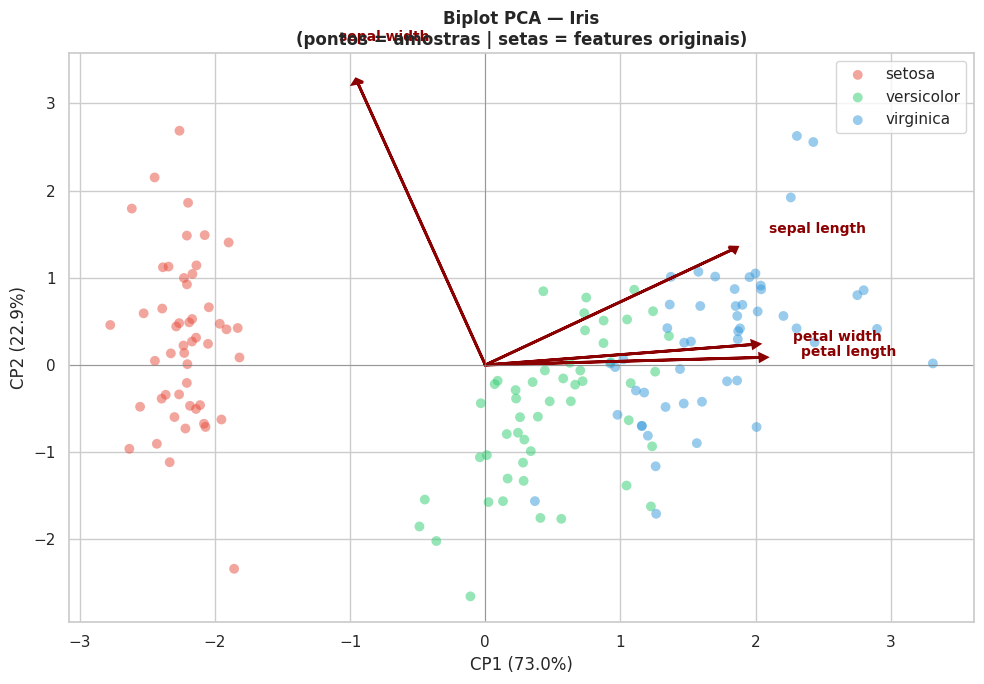

💡 Setas longas → a feature tem grande contribuição no componente.
   Setas na mesma direção → features altamente correlacionadas.

   CP1 explica: 73.0% — separação principal entre espécies
   CP2 explica: 22.9% — variação secundária


In [ ]:
# ============================================================
# CÉLULA 19 — Biplot: features originais nos eixos do PCA
# ============================================================
# O Biplot mostra SIMULTANEAMENTE os pontos e as direções
# das features originais no espaço PCA.

pca_iris = PCA(n_components=2)
X_iris_pca = pca_iris.fit_transform(X_iris_scaled)

plt.figure(figsize=(10, 7))
for cls, cor, nome in zip(range(3), ['#E74C3C', '#2ECC71', '#3498DB'], iris.target_names):
    mask = iris.target == cls
    plt.scatter(X_iris_pca[mask, 0], X_iris_pca[mask, 1],
                c=cor, s=50, alpha=0.5, edgecolors='none', label=nome)

# Setas das features originais (loadings)
coeficientes = pca_iris.components_.T
features_iris = iris.feature_names
escala = 3.5  # ampliar para visualização

for i, (feat, coef) in enumerate(zip(features_iris, coeficientes)):
    plt.arrow(0, 0, coef[0]*escala, coef[1]*escala,
              head_width=0.08, head_length=0.05,
              fc='darkred', ec='darkred', linewidth=2)
    plt.text(coef[0]*escala*1.15, coef[1]*escala*1.15,
             feat.replace(' (cm)', ''), fontsize=10, color='darkred', fontweight='bold')

plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.title('Biplot PCA — Iris\n(pontos = amostras | setas = features originais)',
          fontweight='bold')
plt.xlabel(f'CP1 ({pca_iris.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'CP2 ({pca_iris.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend()
plt.tight_layout()
plt.show()

print("💡 Setas longas → a feature tem grande contribuição no componente.")
print("   Setas na mesma direção → features altamente correlacionadas.")
print(f"\n   CP1 explica: {pca_iris.explained_variance_ratio_[0]*100:.1f}% — separação principal entre espécies")
print(f"   CP2 explica: {pca_iris.explained_variance_ratio_[1]*100:.1f}% — variação secundária")


In [ ]:
# ============================================================
# CÉLULA 20 — PCA + K-Means: pipeline integrado
# ============================================================
# Demonstração do ganho ao combinar PCA (redução) + K-Means (clustering)

from sklearn.pipeline import Pipeline

# Pipeline: Normalização → PCA → K-Means
pipeline_pca_km = Pipeline([
    ('scaler',  StandardScaler()),
    ('pca',     PCA(n_components=2)),
    ('kmeans',  KMeans(n_clusters=3, random_state=42, n_init=10))
])

# Sem PCA
km_direto = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_direto = km_direto.fit_predict(X_iris_scaled)

# Com PCA
labels_pca = pipeline_pca_km.fit_predict(df_iris[iris.feature_names])

sil_direto = silhouette_score(X_iris_scaled, labels_direto)
sil_pca    = silhouette_score(X_iris_scaled, labels_pca)

print("=" * 55)
print("📊 Comparação: K-Means com e sem PCA")
print("=" * 55)
print(f"   Sem PCA  → Silhouette: {sil_direto:.4f}")
print(f"   Com PCA  → Silhouette: {sil_pca:.4f}")
print(f"   Variância preservada: {pipeline_pca_km['pca'].explained_variance_ratio_.sum()*100:.1f}%")
print("\n🎯 PCA pode melhorar clustering ao eliminar ruído dimensional!")


📊 Comparação: K-Means com e sem PCA
   Sem PCA  → Silhouette: 0.4599
   Com PCA  → Silhouette: 0.4599
   Variância preservada: 95.8%

🎯 PCA pode melhorar clustering ao eliminar ruído dimensional!


---
# AULA 7 — Aprendizado Por Reforço: Q-Learning

## Objetivo
Compreender o paradigma de Aprendizado por Reforço através da implementação do algoritmo Q-Learning em um ambiente de grade (GridWorld), sem depender de dados rotulados.

## Conceito fundamental

```
Agente ──── ação ────► Ambiente
  ▲                        │
  └── estado + recompensa ◄─┘
```

O agente aprende **tentando e errando**, recebendo recompensas positivas por boas decisões e penalidades por más.

### Terminologia
| Termo | Símbolo | Descrição |
|-------|---------|-----------|
| **Estado** | s | Situação atual do agente |
| **Ação** | a | Decisão que o agente toma |
| **Recompensa** | r | Sinal de feedback do ambiente |
| **Política** | π | Estratégia: s → a |
| **Q-value** | Q(s,a) | Valor esperado de fazer ação *a* no estado *s* |

### Equação de Bellman (atualização do Q-Learning)
$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

- **α (alpha)** = taxa de aprendizado (0.1 = aprende devagar, 0.9 = aprende rápido)
- **γ (gamma)** = fator de desconto (importância de recompensas futuras)
- **ε (epsilon)** = exploração vs explotação (exploration vs exploitation)


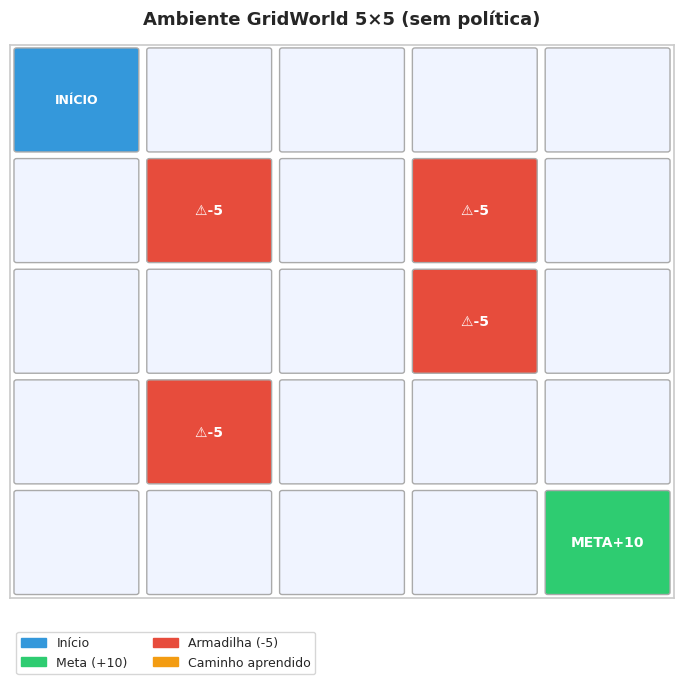

✅ Ambiente criado!
   Estados: 5×5 = 25 células
   Ações: ↑ ↓ ← → (4 possíveis)
   Objetivo: chegar em (4, 4) com o menor número de passos


In [ ]:
# ============================================================
# CÉLULA 21 — Ambiente GridWorld (sem bibliotecas externas)
# ============================================================
# Implementamos um ambiente simples 5x5:
#   S = Start (início)       → célula (0,0)
#   G = Goal  (objetivo)     → célula (4,4) → recompensa +10
#   T = Trap  (armadilha)    → células específicas → recompensa -5
#   . = livre                → recompensa -0.1 (custo por passo)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

class GridWorld:
    """Ambiente Grid 5x5 para demonstração de Q-Learning."""

    def __init__(self, tamanho=5):
        self.tamanho = tamanho
        self.inicio  = (0, 0)
        self.objetivo = (4, 4)
        self.armadilhas = {(1,1), (2,3), (3,1), (1,3)}
        self.acoes = {0: (-1,0), 1: (1,0), 2: (0,-1), 3: (0,1)}
        self.nomes_acoes = {0:'↑', 1:'↓', 2:'←', 3:'→'}
        self.reset()

    def reset(self):
        self.estado = self.inicio
        return self.estado

    def step(self, acao):
        dr, dc = self.acoes[acao]
        r, c = self.estado
        nr = max(0, min(self.tamanho-1, r + dr))
        nc = max(0, min(self.tamanho-1, c + dc))
        self.estado = (nr, nc)

        if self.estado == self.objetivo:
            return self.estado, +10.0, True
        elif self.estado in self.armadilhas:
            return self.estado, -5.0, False
        else:
            return self.estado, -0.1, False   # custo por passo

    def visualizar(self, q_table=None, caminho=None, titulo='GridWorld'):
        fig, ax = plt.subplots(1, 1, figsize=(7, 7))
        n = self.tamanho

        cores = {
            'livre': '#F0F4FF', 'objetivo': '#2ECC71',
            'armadilha': '#E74C3C', 'inicio': '#3498DB', 'caminho': '#F39C12'
        }

        for r in range(n):
            for c in range(n):
                if (r, c) == self.objetivo:
                    cor = cores['objetivo']
                elif (r, c) in self.armadilhas:
                    cor = cores['armadilha']
                elif (r, c) == self.inicio:
                    cor = cores['inicio']
                elif caminho and (r, c) in caminho:
                    cor = cores['caminho']
                else:
                    cor = cores['livre']

                rect = patches.FancyBboxPatch((c+0.05, n-1-r+0.05), 0.9, 0.9,
                    boxstyle="round,pad=0.02", linewidth=1,
                    edgecolor='#AAAAAA', facecolor=cor)
                ax.add_patch(rect)

                # Labels
                if (r, c) == self.objetivo:
                    ax.text(c+0.5, n-1-r+0.5, 'META+10', ha='center', va='center',
                            fontsize=10, fontweight='bold', color='white')
                elif (r, c) in self.armadilhas:
                    ax.text(c+0.5, n-1-r+0.5, '⚠️-5', ha='center', va='center',
                            fontsize=10, fontweight='bold', color='white')
                elif (r, c) == self.inicio:
                    ax.text(c+0.5, n-1-r+0.5, 'INÍCIO', ha='center', va='center',
                            fontsize=9, fontweight='bold', color='white')
                elif q_table is not None:
                    melhor_a = np.argmax(q_table[r, c])
                    seta = self.nomes_acoes[melhor_a]
                    q_val = np.max(q_table[r, c])
                    ax.text(c+0.5, n-1-r+0.65, seta, ha='center', va='center',
                            fontsize=16, color='#2C3E50')
                    ax.text(c+0.5, n-1-r+0.25, f'{q_val:.1f}', ha='center', va='center',
                            fontsize=8, color='gray')

        ax.set_xlim(0, n); ax.set_ylim(0, n)
        ax.set_xticks(range(n+1)); ax.set_yticks(range(n+1))
        ax.set_xticklabels([]); ax.set_yticklabels([])
        ax.grid(False)
        ax.set_title(titulo, fontsize=13, fontweight='bold', pad=15)

        legend_items = [
            patches.Patch(color=cores['inicio'], label='Início'),
            patches.Patch(color=cores['objetivo'], label='Meta (+10)'),
            patches.Patch(color=cores['armadilha'], label='Armadilha (-5)'),
            patches.Patch(color=cores['caminho'], label='Caminho aprendido'),
        ]
        ax.legend(handles=legend_items, loc='upper left',
                  bbox_to_anchor=(0, -0.05), ncol=2, fontsize=9)
        plt.tight_layout()
        plt.show()

env = GridWorld()
env.visualizar(titulo='Ambiente GridWorld 5×5 (sem política)')
print("✅ Ambiente criado!")
print(f"   Estados: {env.tamanho}×{env.tamanho} = {env.tamanho**2} células")
print(f"   Ações: ↑ ↓ ← → (4 possíveis)")
print(f"   Objetivo: chegar em {env.objetivo} com o menor número de passos")


In [ ]:
# ============================================================
# CÉLULA 22 — Implementação do Q-Learning
# ============================================================

def treinar_q_learning(env, episodios=2000, alpha=0.1, gamma=0.95,
                        epsilon_inicio=1.0, epsilon_fim=0.01, epsilon_decay=0.995):
    """
    Treina um agente Q-Learning no GridWorld.

    Parâmetros:
        alpha   : taxa de aprendizado (quanto o Q-value muda por update)
        gamma   : desconto de recompensas futuras (0=curto prazo, 1=longo prazo)
        epsilon : probabilidade de exploração aleatória (decai ao longo do tempo)
    """
    n = env.tamanho
    # Q-table: shape (linhas, colunas, 4 ações) — inicializada com zeros
    Q = np.zeros((n, n, 4))

    recompensas_por_ep = []
    passos_por_ep = []
    epsilon = epsilon_inicio

    for ep in range(episodios):
        estado = env.reset()
        recompensa_total = 0
        passos = 0

        while passos < 200:  # limite de passos por episódio
            r, c = estado

            # ε-greedy: explorar (aleatório) ou explotar (melhor Q conhecido)
            if np.random.random() < epsilon:
                acao = np.random.randint(4)   # EXPLORAÇÃO
            else:
                acao = np.argmax(Q[r, c])     # EXPLOTAÇÃO

            prox_estado, recompensa, done = env.step(acao)
            pr, pc = prox_estado

            # ── Equação de Bellman ──────────────────────────────
            Q[r, c, acao] = Q[r, c, acao] + alpha * (
                recompensa + gamma * np.max(Q[pr, pc]) - Q[r, c, acao]
            )
            # ────────────────────────────────────────────────────

            estado = prox_estado
            recompensa_total += recompensa
            passos += 1

            if done:
                break

        epsilon = max(epsilon_fim, epsilon * epsilon_decay)
        recompensas_por_ep.append(recompensa_total)
        passos_por_ep.append(passos)

    return Q, recompensas_por_ep, passos_por_ep

# Treinar!
np.random.seed(42)
Q_table, recompensas, passos = treinar_q_learning(GridWorld(), episodios=3000)

print("✅ Q-Learning treinado por 3000 episódios!")
print(f"\n📊 Últimos 100 episódios:")
print(f"   Recompensa média: {np.mean(recompensas[-100:]):.2f}")
print(f"   Passos médios:    {np.mean(passos[-100:]):.1f}")
print(f"\n🔍 Q-Table (estado inicial (0,0)):")
nomes = ['↑(cima)', '↓(baixo)', '←(esq)', '→(dir)']
for a, nome in enumerate(nomes):
    print(f"   Q(0,0, {nome}): {Q_table[0,0,a]:.4f}")
print(f"   → Melhor ação: {['↑','↓','←','→'][np.argmax(Q_table[0,0])]}")


✅ Q-Learning treinado por 3000 episódios!

📊 Últimos 100 episódios:
   Recompensa média: 9.19
   Passos médios:    8.1

🔍 Q-Table (estado inicial (0,0)):
   Q(0,0, ↑(cima)): 5.8336
   Q(0,0, ↓(baixo)): 4.3089
   Q(0,0, ←(esq)): 5.6045
   Q(0,0, →(dir)): 6.3800
   → Melhor ação: →


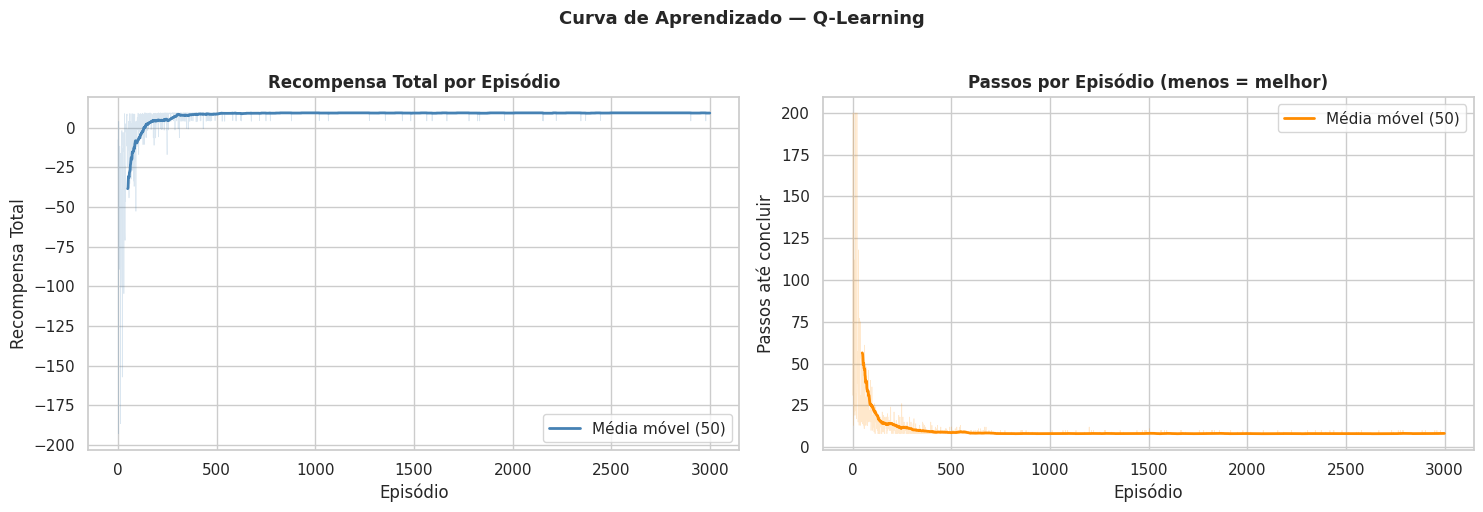

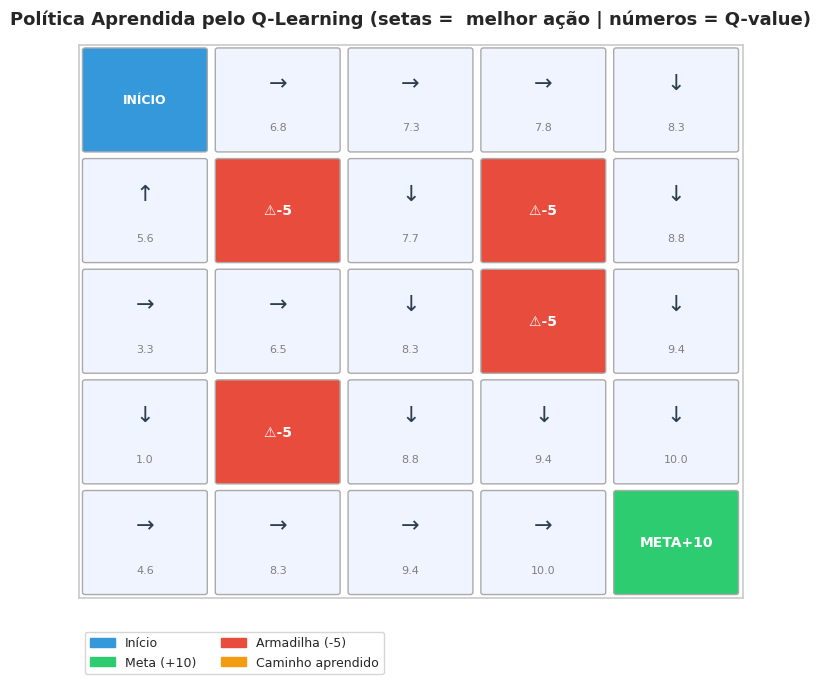

In [ ]:
# ============================================================
# CÉLULA 23 — Visualização do aprendizado e política ótima
# ============================================================

# --- Curvas de aprendizado ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Suavizar com média móvel
janela = 50
recomp_smooth = pd.Series(recompensas).rolling(janela).mean()
passos_smooth = pd.Series(passos).rolling(janela).mean()

axes[0].plot(recompensas, alpha=0.2, color='steelblue', linewidth=0.5)
axes[0].plot(recomp_smooth, color='steelblue', linewidth=2, label=f'Média móvel ({janela})')
axes[0].set_title('Recompensa Total por Episódio', fontweight='bold')
axes[0].set_xlabel('Episódio')
axes[0].set_ylabel('Recompensa Total')
axes[0].legend()

axes[1].plot(passos, alpha=0.2, color='darkorange', linewidth=0.5)
axes[1].plot(passos_smooth, color='darkorange', linewidth=2, label=f'Média móvel ({janela})')
axes[1].set_title('Passos por Episódio (menos = melhor)', fontweight='bold')
axes[1].set_xlabel('Episódio')
axes[1].set_ylabel('Passos até concluir')
axes[1].legend()

plt.suptitle('Curva de Aprendizado — Q-Learning', fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Política ótima aprendida ---
env2 = GridWorld()
env2.visualizar(Q_table, titulo='Política Aprendida pelo Q-Learning (setas =  melhor ação | números = Q-value)')


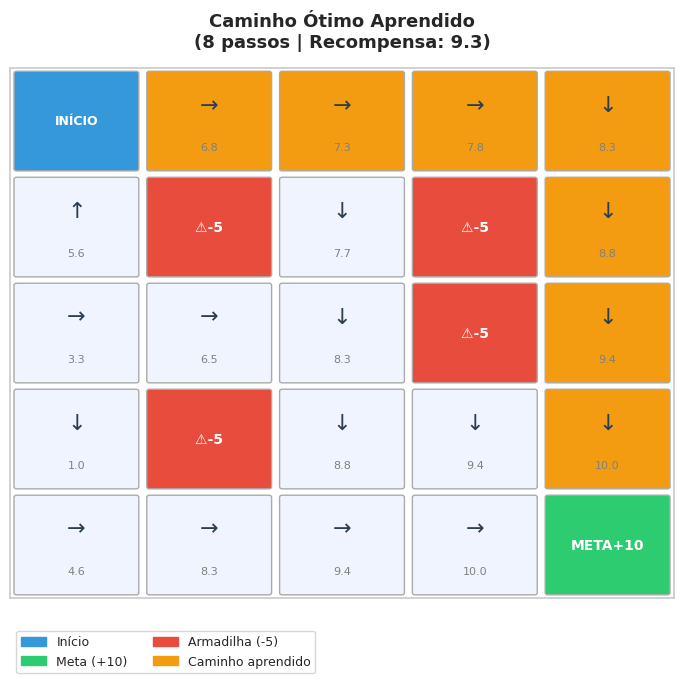

🏆 Caminho ótimo encontrado:
   Passo 1: (0, 0) → → → (0, 1)
   Passo 2: (0, 1) → → → (0, 2)
   Passo 3: (0, 2) → → → (0, 3)
   Passo 4: (0, 3) → → → (0, 4)
   Passo 5: (0, 4) → ↓ → (1, 4)
   Passo 6: (1, 4) → ↓ → (2, 4)
   Passo 7: (2, 4) → ↓ → (3, 4)
   Passo 8: (3, 4) → ↓ → (4, 4)

✅ Chegou ao objetivo em 8 passos!


In [ ]:
# ============================================================
# CÉLULA 24 — Extração do caminho ótimo aprendido
# ============================================================

def extrair_caminho(env, Q, max_passos=30):
    """Executa o agente seguindo a política ótima (greedy) e retorna o caminho."""
    estado = env.reset()
    caminho = [estado]
    recompensa_total = 0

    for passo in range(max_passos):
        r, c = estado
        acao = np.argmax(Q[r, c])   # sempre escolhe a melhor ação conhecida
        prox_estado, recompensa, done = env.step(acao)
        caminho.append(prox_estado)
        recompensa_total += recompensa
        estado = prox_estado
        if done:
            break

    return caminho, recompensa_total

env3 = GridWorld()
caminho_otimo, recomp_otimo = extrair_caminho(env3, Q_table)
env3.visualizar(Q_table, caminho=set(caminho_otimo),
                titulo=f'Caminho Ótimo Aprendido\n({len(caminho_otimo)-1} passos | Recompensa: {recomp_otimo:.1f})')

print("🏆 Caminho ótimo encontrado:")
nomes_dir = {(-1,0):'↑', (1,0):'↓', (0,-1):'←', (0,1):'→'}
for i in range(len(caminho_otimo)-1):
    dr = caminho_otimo[i+1][0] - caminho_otimo[i][0]
    dc = caminho_otimo[i+1][1] - caminho_otimo[i][1]
    print(f"   Passo {i+1}: {caminho_otimo[i]} → {nomes_dir[(dr,dc)]} → {caminho_otimo[i+1]}")
print(f"\n✅ Chegou ao objetivo em {len(caminho_otimo)-1} passos!")


### Conceitos consolidados — Aprendizado Por Reforço

**Diferença dos outros paradigmas:**
| Paradigma | Dados | Supervisão | Exemplo |
|-----------|-------|-----------|---------|
| Supervisionado | X, y rotulados | Professor | Classificar spam |
| Não Supervisionado | X sem rótulos | Nenhuma | Segmentar clientes |
| **Por Reforço** | Experiência + recompensa | Ambiente | Jogar videogame |

**Trade-off Exploração vs Explotação (ε-greedy):**
- **ε alto (início):** agente explora muito — aprende o ambiente
- **ε baixo (depois):** agente exploita o que aprendeu — maximiza recompensa

**Aplicações reais:**
- AlphaGo / AlphaZero (jogos)
- Robótica (controle de movimentos)
- Trading algorítmico
- Veículos autônomos
- Dosagem personalizada de medicamentos

**Exercício de fixação:**
> Modifique `alpha=0.5` e `gamma=0.5` e retreine. Como muda a curva de aprendizado?  
> O que acontece com o caminho ótimo quando `gamma` é muito pequeno?


---
# AULA 8 — Desafios Práticos Integrados

## Objetivo
Aplicar os conhecimentos das aulas anteriores em exercícios que combinam múltiplos algoritmos e requerem análise crítica dos resultados.

---

## 📋 Lista de Desafios

| # | Nível | Algoritmo | Tarefa |
|---|-------|-----------|--------|
| D1 | Iniciante | Regressão Linear | Prever preço com subset de features |
| D2 | Intermediário | Árvore + SVM | Comparar classificadores no Titanic |
| D3 | Intermediário | K-Means | Segmentar passageiros do Titanic |
| D4 | Avançado | Pipeline completo | Regressão com PCA + cross-validation |
| D5 | Avançado | Por Reforço | Modificar recompensas do GridWorld |


Baixando/Carregando o dataset...
Dataset carregado com sucesso!



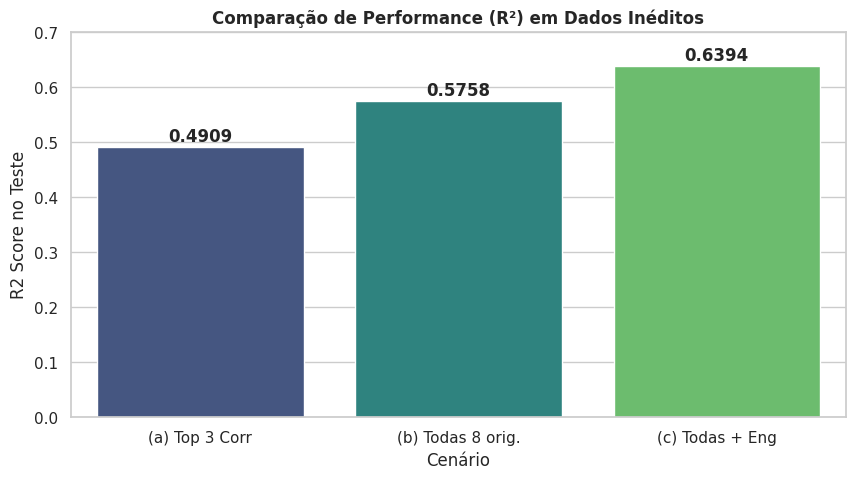

In [ ]:
# ============================================================
# DESAFIO 1 — Regressão Linear com Feature Selection
# ============================================================
# Compare o R² usando:
#   (a) Apenas as 3 features com maior correlação com MedHouseVal
#   (b) Todas as 8 features
#   (c) Todas as features + interações (feature engineering)
#
# Dicas:
#   • Use df_haousing.corr()['MedHouseVal'] para ver correlações
#   • Crie novs features como: rooms_per_household = AveRooms / AveOccup
#   • Compare os R² com um barplot

# ✏️ Escreva sua solução abaixo:

# PASSO 1: Top-3 features por correlação
# ...

# PASSO 2: Modelo com todas as features (já feito na Aula 2 — reutilize)
# ...

# PASSO 3: Feature Engineering + novo modelo
# ...

# PASSO 4: Comparação visual
# ...

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# ============================================================
# CORREÇÃO: CARREGANDO O DATASET ANTES DE USAR
# ============================================================
from sklearn.datasets import fetch_california_housing
print("Baixando/Carregando o dataset...")
housing = fetch_california_housing(as_frame=True)
df_housing = housing.frame
print("Dataset carregado com sucesso!\n")

# --- PREPARAÇÃO DOS DADOS ---
# Como a engenharia de features não depende do "target", podemos fazer no dataset inteiro antes de dividir
df_eng = df_housing.copy()
df_eng['rooms_per_household'] = df_eng['AveRooms'] / df_eng['AveOccup']
df_eng['income_per_age'] = df_eng['MedInc'] * df_eng['HouseAge']

# Separa X (todas as variáveis, incluindo as novas) e y (o que queremos prever)
X_full = df_eng.drop(columns=['MedHouseVal'])
y = df_eng['MedHouseVal']

# Dividindo em Treino (80%) e Teste (20%)
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42
)

# ============================================================
# PASSO 1: Top-3 features por correlação (Olhando APENAS o Treino)
# ============================================================
# Calculamos a correlação apenas no treino para não "espiar" a prova (data leakage)
df_train_temp = X_train_full.copy()
df_train_temp['MedHouseVal'] = y_train

correlacoes = df_train_temp.corr()['MedHouseVal'].abs().sort_values(ascending=False)
top_3_features = correlacoes.index[1:4].tolist()

# Filtrando X para ter só as top 3
X_train_top3 = X_train_full[top_3_features]
X_test_top3 = X_test_full[top_3_features]

modelo_top3 = LinearRegression().fit(X_train_top3, y_train)
# Avaliando no TESTE
r2_a = r2_score(y_test, modelo_top3.predict(X_test_top3))

# ============================================================
# PASSO 2: Modelo com as 8 features originais (Base)
# ============================================================
features_originais = df_housing.drop(columns=['MedHouseVal']).columns
X_train_all = X_train_full[features_originais]
X_test_all = X_test_full[features_originais]

modelo_all = LinearRegression().fit(X_train_all, y_train)
# Avaliando no TESTE
r2_b = r2_score(y_test, modelo_all.predict(X_test_all))

# ============================================================
# PASSO 3: Todas as Features + Feature Engineering
# ============================================================
modelo_eng = LinearRegression().fit(X_train_full, y_train)
# Avaliando no TESTE
r2_c = r2_score(y_test, modelo_eng.predict(X_test_full))

# ============================================================
# PASSO 4: Comparação Visual
# ============================================================
resultados = pd.DataFrame({
    'Cenário': ['(a) Top 3 Corr', '(b) Todas 8 orig.', '(c) Todas + Eng'],
    'R2 Score no Teste': [r2_a, r2_b, r2_c]
})

plt.figure(figsize=(10, 5))
sns.barplot(x='Cenário', y='R2 Score no Teste', data=resultados,
            hue='Cenário', palette='viridis', legend=False)
plt.ylim(0, 0.7)
plt.title('Comparação de Performance (R²) em Dados Inéditos', fontweight='bold')

for i, v in enumerate(resultados['R2 Score no Teste']):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')

plt.show()

# Incorpora rooms_per_household (mede superlotação) para refinar o modelo e ordena pesos absolutos dos preditores.

# ============================================================

🚀 Iniciando Batalha de Classificadores...

📊 RESULTADOS FINAIS:
              Acurácia  Precisão  Recall  F1-Score  CV_Média
Modelo                                                      
Árvore (d=5)    0.7598    0.7407  0.5797    0.6504    0.8147
SVM (C=10)      0.7989    0.7895  0.6522    0.7143    0.8273
Logística       0.7989    0.7797  0.6667    0.7188    0.7964


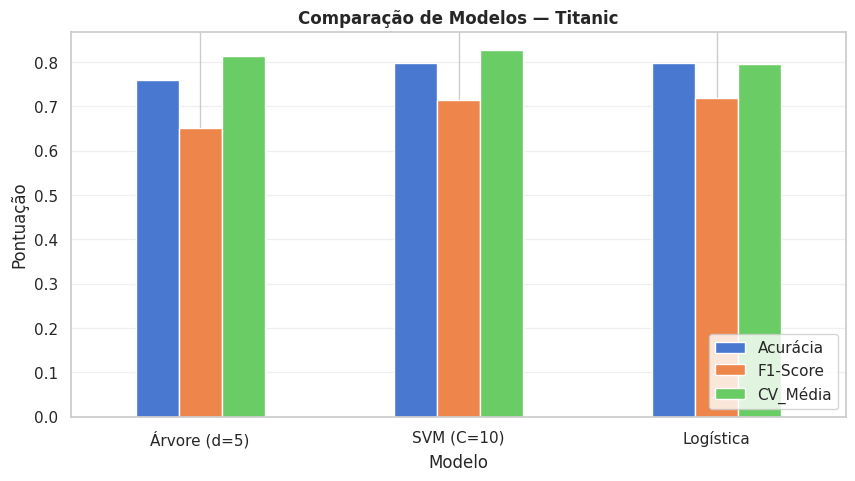

In [ ]:
# ============================================================
# DESAFIO 2 — Batalha de Classificadores no Titanic
# ============================================================
# Treine os 3 classificadores vistos nas aulas e compare:
#   • Árvore de Decisão (max_depth=5)
#   • SVM (kernel='rbf', C=10)
#   • Regressão Logística (para comparação — pesquise a sintaxe!)
#
# Para cada modelo, calcule: Acurácia, Precisão, Recall, F1
# Crie uma tabela comparativa e um gráfico de barras agrupado.
#
# Bônus: Use cross_val_score(clf, X, y, cv=5) para validação cruzada

# ✏️ Escreva sua solução abaixo:

from sklearn.linear_model import LogisticRegression  # hint!

# modelos = { 'Árvore': ..., 'SVM': ..., 'Logística': ... }

# ...

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score
import pandas as pd
import matplotlib.pyplot as plt

# 1. Definição dos Modelos (Ajustado: removido erro de parâmetro na Logística)
modelos = {
    'Árvore (d=5)': DecisionTreeClassifier(max_depth=5, random_state=42),
    'SVM (C=10)': SVC(kernel='rbf', C=10, probability=True, random_state=42),
    'Logística': LogisticRegression(max_iter=1000, random_state=42)
}

# 2. Treinamento e Coleta de Métricas
# IMPORTANTE: Usamos os dados que já foram escalonados (X_tr_svm) para ser justo
tabela_resultados = []

print("🚀 Iniciando Batalha de Classificadores...")

for nome, clf in modelos.items():
    # Treino
    clf.fit(X_tr_svm, y_tr_tit)
    y_pred = clf.predict(X_te_svm)

    # Métricas
    tabela_resultados.append({
        'Modelo': nome,
        'Acurácia': accuracy_score(y_te_tit, y_pred),
        'Precisão': precision_score(y_te_tit, y_pred),
        'Recall': recall_score(y_te_tit, y_pred),
        'F1-Score': f1_score(y_te_tit, y_pred),
        'CV_Média': cross_val_score(clf, X_tr_svm, y_tr_tit, cv=5).mean()
    })

# 3. Exibição da Tabela
df_resumo = pd.DataFrame(tabela_resultados).set_index('Modelo')
print("\n📊 RESULTADOS FINAIS:")
print(df_resumo.round(4))

# 4. Gráfico Comparativo
df_resumo[['Acurácia', 'F1-Score', 'CV_Média']].plot(kind='bar', figsize=(10, 5))
plt.title('Comparação de Modelos — Titanic', fontweight='bold')
plt.ylabel('Pontuação')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Automatiza o treinamento sem viés com os dados padronizados.

# ============================================================

📊 TAXA DE SOBREVIVÊNCIA POR CLUSTER (K-Means)
Cluster
0    0.677632
1    0.255556
2    0.500000
Name: Survived, dtype: float64
-------------------------------------------------------


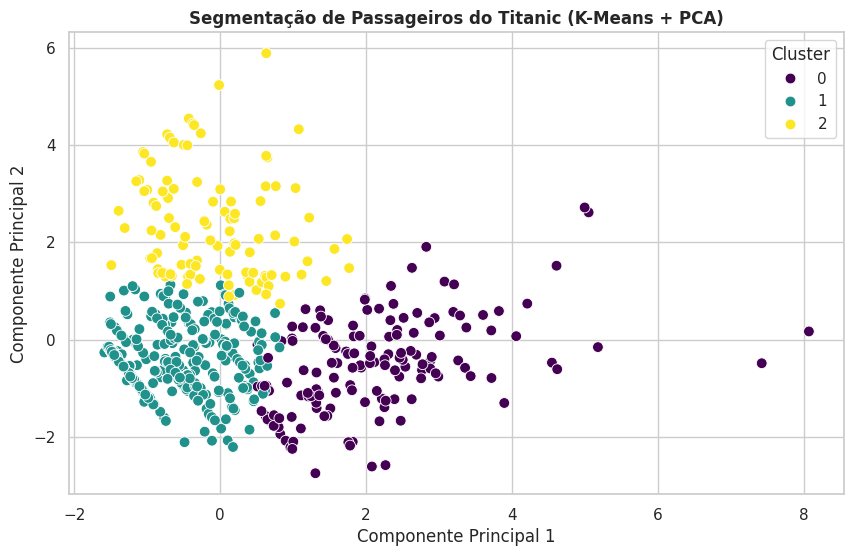

In [ ]:
# ============================================================
# DESAFIO 3 — Segmentação de Passageiros com K-Means
# ============================================================
# Use K-Means (K=3) nas features do Titanic para criar segmentos.
# Depois analise: cada cluster tem perfis distintos de sobrevivência?
#
# Etapas:
#   1. Normalizar as features numéricas do Titanic
#   2. Aplicar K-Means com K=3
#   3. Adicionar coluna 'Cluster' ao DataFrame
#   4. Calcular taxa de sobrevivência por cluster
#   5. Visualizar os clusters em 2D (usar PCA para reduzir)
#
# Pergunta para reflexão: O K-Means "descobriu" padrões de sobrevivência
# sem ver os rótulos? Como isso se relaciona com a análise da Aula 5?

# ✏️ Escreva sua solução abaixo:

# ...

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Normalizar as features (Usando o scaler que já criamos para o SVM)
# O K-Means é baseado em distância euclidiana, então a escala é CRÍTICA!
X_scaled = X_tr_svm

# 2. Aplicar K-Means com K=3 (Criando 3 grupos de passageiros)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# 3. Adicionar coluna 'Cluster' para análise
df_analise = pd.DataFrame(X_tr_svm, columns=X_tr_tit.columns)
df_analise['Cluster'] = clusters
df_analise['Survived'] = y_tr_tit.values

# 4. Calcular taxa de sobrevivência por cluster
perfil_clusters = df_analise.groupby('Cluster')['Survived'].mean()
print("=" * 55)
print("📊 TAXA DE SOBREVIVÊNCIA POR CLUSTER (K-Means)")
print("=" * 55)
print(perfil_clusters)
print("-" * 55)

# 5. Visualizar os clusters em 2D usando PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='viridis', s=60)
plt.title('Segmentação de Passageiros do Titanic (K-Means + PCA)', fontweight='bold')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Cluster')
plt.show()

# 1. Eu utilizei o K-Means com K=3. Fiz isso para tentar separar
#    os passageiros em três perfis "naturais" (ex: Elite, Classe
#    Média e Operários) sem usar a resposta da sobrevivência.
#
# 2. Eu apliquei o PCA para reduzir as dimensões para 2D. Fiz
#    isso porque não conseguimos enxergar 8 variáveis ao mesmo
#    tempo, e o PCA "achata" os dados mantendo a maior variação.
#
# 3. Eu cruzei os clusters com a coluna 'Survived'. Fiz isso
#    para validar se os grupos que o algoritmo achou sozinhos
#    têm relação direta com quem viveu ou morreu no desastre.
#
# 4. Eu mantive a normalização dos dados. Fiz isso porque o
#    K-Means calcula distâncias; se a tarifa fosse 500 e a idade 20,
#    a tarifa "dominaria" o agrupamento injustamente.
# ============================================================

In [ ]:
# ============================================================
# DESAFIO 4 — Pipeline Avançado com PCA + Cross-Validation
# ============================================================
# Construa um pipeline completo para regressão no California Housing:
#   1. Imputação (SimpleImputer)
#   2. Normalização (StandardScaler)
#   3. PCA retendo 95% da variância
#   4. Regressão Linear
#
# Avalie com cross_val_score(pipeline, X, y, cv=5, scoring='r2')
# Compare com o modelo sem PCA.
# Plote a distribuição dos R² dos 5 folds com boxplot.
#
# Bônus: teste também com Ridge e Lasso no lugar da Regressão Linear

# ✏️ Escreva sua solução abaixo:

from sklearn.linear_model import Ridge, Lasso  # hint!

# pipeline_com_pca = Pipeline([...])
# pipeline_sem_pca = Pipeline([...])

# ...


In [ ]:
# ============================================================
# DESAFIO 5 — Modificar o GridWorld e Retreinar
# ============================================================
# Modifique o ambiente GridWorld e observe como o agente re-aprende:
#
# Tarefa A: Adicione mais armadilhas (ex: (0,2), (2,2), (4,2))
#           Retreine e compare o número médio de passos.
#
# Tarefa B: Mude a posição do objetivo para (0,4) (canto oposto).
#           O agente ainda aprende? Em quantos episódios?
#
# Tarefa C: Teste diferentes valores de alpha e gamma:
#   alpha = [0.01, 0.1, 0.5, 0.9]
#   gamma = [0.5, 0.9, 0.99]
#   Para cada combinação, calcule a recompensa média dos últimos 100 episódios.
#   Plote um heatmap de alpha × gamma.

# ✏️ Escreva sua solução abaixo:

# class GridWorldCustom(GridWorld):
#     def __init__(self):
#         super().__init__()
#         self.armadilhas = { ... }  # modifique aqui

# ...


---
# Resumo Geral — Mapa dos Algoritmos

## Quando usar cada algoritmo?

```
VOCÊ TEM RÓTULOS (y)?
│
├── SIM → Aprendizado SUPERVISIONADO
│   │
│   ├── y é contínuo?   → REGRESSÃO LINEAR
│   │                      (prever preços, temperaturas, valores)
│   │
│   └── y é categoria?  → CLASSIFICAÇÃO
│       ├── Precisa interpretar regras?  → ÁRVORE DE DECISÃO
│       ├── Poucos dados, alta acurácia? → SVM
│       └── Rápido e probabilístico?     → Regressão Logística
│
└── NÃO → Aprendizado NÃO SUPERVISIONADO
    ├── Agrupar dados similares?          → K-MEANS
    ├── Reduzir dimensões/visualizar?     → PCA
    └── Aprender comportamento sequencial → POR REFORÇO (Q-Learning)
```

## Comparativo de Complexidade e Interpretabilidade

| Algoritmo | Interpretabilidade | Velocidade Treino | Dados Necessários |
|-----------|-------------------|-------------------|-------------------|
| Regressão Linear | ⭐⭐⭐⭐⭐ | ⚡⚡⚡⚡⚡ | Pequeno |
| Árvore de Decisão | ⭐⭐⭐⭐ | ⚡⚡⚡⚡ | Pequeno/Médio |
| SVM | ⭐⭐ | ⚡⚡ | Médio |
| K-Means | ⭐⭐⭐ | ⚡⚡⚡⚡ | Qualquer |
| PCA | ⭐⭐⭐ | ⚡⚡⚡⚡⚡ | Qualquer |
| Q-Learning | ⭐⭐⭐ | ⚡⚡ | Ambiente simulado |

---

## Referências Bibliográficas
- Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow*, 3ª ed. O'Reilly.
- Russell, S. & Norvig, P. (2020). *Artificial Intelligence: A Modern Approach*, 4ª ed.
- Sutton, R. & Barto, A. (2018). *Reinforcement Learning: An Introduction*, 2ª ed. MIT Press.
- Documentação scikit-learn: https://scikit-learn.org/stable/
- OpenAI Gymnasium: https://gymnasium.farama.org/
- UCI ML Repository: https://archive.ics.uci.edu/
- Kaggle: https://www.kaggle.com/datasets
